# =================================================================== (Sparse Reward)
# **Arquitectura 1 Joint: FeUdal Networks — Entrenament Conjunt (Single-Phase)**
# ===================================================================

**Objectiu**: Implementar agent HRL amb entrenament conjunt Manager+Worker simultani.

Aquest notebook implementa l'arquitectura FeudalAgent amb entrenament conjunt, variant del notebook base `04_hrl_agent.ipynb`.

**Arquitectura**: FC-only (sense recurrència)

**Key Changes**:
- Manager i Worker s'entrenen simultàniament (no hi ha fases de congelació)
- Cap reset d'optimitzadors durant entrenament
- Mantingut: Manager actualitza cada `c` passos (temporal abstraction)

In [1]:
# CEL·LA 1 — IMPORTS

import json
import math
import os as _os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, List, Tuple
from codecarbon import EmissionsTracker
from torch.distributions import Categorical, Normal
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

# ── SB3: RolloutBuffer i callbacks (NO la classe PPO) ─────────────────────────────
# RolloutBuffer: infraestructura de referència; HierarchicalRolloutBuffer
# l'estén per a l'arquitectura FeUdal dual (Worker pas a pas, Manager cada c).
from stable_baselines3.common.buffers import RolloutBuffer  # noqa: F401
from stable_baselines3.common.callbacks import BaseCallback

# ── Project ──────────────────────────────────────────────────────────────────────
from src.data.manager import DataManager
from src.rl.envs.crypto_market_env_consolidated_reward import (
    CryptoMarketEnvConsolidatedReward, INITIAL_BALANCE, MAX_EPISODE_STEPS, MIN_EPISODE_STEPS,
     LOG_COLS,
    HOLD_PENALTY, DD_THRESHOLD, DD_PENALTY, OPEN_POSITION_PENALTY, steps_per_4h_for,
)
from src.rl.metrics import compute_sharpe, compute_max_drawdown
from src.rl.model_summary import model_summary
from src.rl.utils import narrow, narrow_int, fee_curriculum_factor
from src.rl.visualization import plot_optuna_search, plot_training_curves, plot_walk_forward

# Pre-training support
from src.rl.training.pretrain_hrl import (
    PreTrainingConfig, SyntheticPhaseConfig, pretrain_and_train_hrl
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [2]:
# CEL·LA 2 — CONFIGURACIÓ: SEED, DEVICE, PATHS, HIPERPARÀMETRES

# ═══════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITAT
# ═══════════════════════════════════════════════════════════════════════════
SEED = 42  # Seed estàndard ML/DL per reproducibilitat

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# ═══════════════════════════════════════════════════════════════════════════
# PRE-TRAINING (SYNTHETIC DATA BOOTSTRAP)
# ═══════════════════════════════════════════════════════════════════════════
PRE_TRAINING = False  # Set True to enable pre-training with synthetic data
PRE_TRAIN_PHASE1_STEPS = 100_000   # Fixed frequency sine
PRE_TRAIN_PHASE2_STEPS = 100_000   # Chirp (frequency sweep)
PRE_TRAIN_PHASE3_STEPS = 100_000   # Fractal multi-frequency

# ═══════════════════════════════════════════════════════════════════════════
# PROTOCOL 3 FASES (Manager-Worker Alternating Training)
# ═══════════════════════════════════════════════════════════════════════════
# Fase 1: Manager bootstrap (Worker congelat)
# Fase 2: Worker bootstrap (Manager congelat)
# Fase 3: Alternança Manager-Worker (refinament)
# Curriculum learning: Transició alignment→extrinsic reward

# Manager alignment loss coefficient (TPG gradient scaling)
ALIGN_COEF = 0.1  # Coeficient per balance alignment vs entropy

# ═══════════════════════════════════════════════════════════════════════════
# CURRICULUM LEARNING: Alpha/Beta Decay (Manager/Worker Rewards)
# ═══════════════════════════════════════════════════════════════════════════
# Alpha: Manager reward transition (alignment → extrinsic)
# CONFIGURACIÓ A (TPG PUR): Segueix exactament el paper FuN (Vezhnevets et al. 2017)
ALPHA_MODE = 'constant'    # 'constant' | 'decreasing' | 'increasing'
ALPHA_DECAY_0 = 1.0        # Sempre 100% alignment (TPG pur, no extrinsic reward)
ALPHA_DECAY_FINAL = 1.0    # Mantingut constant durant tot l'entrenament
ALPHA_DECAY_H = 3.0        # Half-life en cycles (no s'usa amb mode 'constant')

# Beta: Worker reward transition (intrinsic ↔ extrinsic)
BETA_MODE = 'constant'     # 'constant' | 'decreasing' | 'increasing'
BETA_CONSTANT = 0.75        # 75% intrinsic, 25% extrinsic (FuN paper: "small coefficient")
BETA_DECAY_0 = 1.0         # Per mode 'decreasing' (inicial)
BETA_DECAY_FINAL = 0.0     # Per mode 'increasing' (final)
BETA_DECAY_H = 5.0         # Half-life en cycles

# Notes:
# - Alpha 'constant' α=1.0 (CONFIGURACIÓ A): Manager NOMÉS aprèn amb alignment reward (TPG pur)
#   Aquesta configuració segueix exactament el paper de FeUdal Networks.
# - Beta 'constant' β=1.0 (recomanat): Worker sempre segueix Manager (FuN original)
# - Desviació del paper només es recomana per estudis d'ablació documentats.


# ═══════════════════════════════════════════════════════════════════════════
# PATHS I IDENTIFICADORS
# ═══════════════════════════════════════════════════════════════════════════
# Ajustar CWD si estem dins notebooks/
_cwd = Path.cwd()
if not (_cwd / "data" / "processed").exists():
    _root = _cwd.parents[1]
    if (_root / "data" / "processed").exists():
        _os.chdir(_root)
        print(f"CWD -> {Path.cwd()}")

# Directoris d'output
CHECKPOINTS    = Path("checkpoints_sparse"); CHECKPOINTS.mkdir(exist_ok=True)
RESULTS        = Path("results_sparse") / "05s_hrl_FeUdal_agent_paper_1ph_pt"
RESULTS.mkdir(parents=True, exist_ok=True)
RUNS_DIR       = RESULTS / "runs"; RUNS_DIR.mkdir(parents=True, exist_ok=True)
CODECARBON_DIR = RESULTS / "codecarbon"; CODECARBON_DIR.mkdir(parents=True, exist_ok=True)
HRL_CKPT_DIR   = CHECKPOINTS / "hrl_sparse_feudal_agent_paper_1ph_pt"
HRL_CKPT_DIR.mkdir(parents=True, exist_ok=True)
OPTUNA_STORAGE_DIR = RESULTS / "optuna_db"; OPTUNA_STORAGE_DIR.mkdir(parents=True, exist_ok=True)

NB_TAG = "paper"  # Identificador únic notebook (per study_name Optuna)

# Fitxers de persistència JSON (Optuna best params)
OPTUNA_HRL_P1_JSON    = RESULTS / "optuna_hrl_p1_best_params.json"
OPTUNA_HRL_P2_JSON    = RESULTS / "optuna_hrl_p2_best_params.json"
OPTUNA_HRL_FINAL_JSON = RESULTS / "optuna_hrl_final_best_params.json"

# ═══════════════════════════════════════════════════════════════════════════
# DADES I FEATURES
# ═══════════════════════════════════════════════════════════════════════════
TIMEFRAME    = "60m"  # Interval temporal (5m, 15m, 60m, 240m, 1440m)
PROJECT      = "nb05d_hrl_feudal"
dm           = DataManager(interval=TIMEFRAME, project_root=Path("."))
FEATURE_COLS = dm.features
N_FEATURES   = len(FEATURE_COLS)

# ═══════════════════════════════════════════════════════════════════════════
# HIPERPARÀMETRES FIXOS (NO OPTIMITZABLES VIA OPTUNA)
# ═══════════════════════════════════════════════════════════════════════════
FIXED_HP = {
    'vf_coef': 0.5,                # Value function loss coefficient (PPO standard)
    'max_grad_norm': 0.5,          # Worker gradient clipping norm
    'manager_max_grad_norm': 5.0,  # Manager gradient clipping (TPG més permissiu)
    'reward_scale': 1.0,           # Scaling extrinsic reward per Manager
    'weight_decay': 0.0,           # L2 regularització (AdamW)
    'std_max': 0.0,                # Std max per action distribution (0=no cap)
    'batch_size': 256,             # PPO minibatch size
    'n_epochs': 10,                # PPO epochs per update
    'clip_range': 0.2,             # PPO clipping ε (0.1-0.3 standard)
}

# ═══════════════════════════════════════════════════════════════════════════
# ARQUITECTURA FEUDAL NETWORKS (Vezhnevets et al. 2017)
# ═══════════════════════════════════════════════════════════════════════════
# Paper FuN: https://arxiv.org/abs/1703.01161
# Arquitectura:
#   obs → Perception → z(64) → Manager (LSTM) → g(32)
#                       ↓
#                    Worker (LSTM) → U(A×K) · φ(g)=w(K) → logits(A)
#
# Manager genera goals g ∈ R^32 cada c=5 passos
# Worker rep z + Σg_{t-c:t} i genera accions a cada pas
# Worker recompensa intrínseca: r^I = cos_sim(Δz, g)
# Manager recompensa: r^M = alignment (transició a extrinsic via α_t)

# ───────────────────────────────────────────────────────────────────────────
# ARQUITECTURA FUNCTION TYPE (Extensible)
# ───────────────────────────────────────────────────────────────────────────
FUNCTION_TYPE = "recurrent"  # "recurrent" (LSTM) | "fc_lineal" (MLP 3×[32,32,32])

# Si FUNCTION_TYPE="fc_lineal" (ablation study):
#   - fMrnn: MLP 3 capes [32→32→32→32] amb Tanh (darrera lineal)
#   - fWrnn: MLP 3 capes [32→32→32→32] amb Tanh (darrera lineal)
#   - NO hidden state (feedforward stateless)
#   - Reducció: 10,560 params (41.3% menys que LSTM)
#   - Útil per avaluar necessitat de memòria temporal en HRL trading

Z_DIM = 64   # Dimensió representació latent z (percept features)
G_DIM = 32   # Dimensió goal Manager g (subgoal space)
K_DIM = 8    # Dimensió key φ(g)=w per Worker (paper: k=16, aquí k=8)

# Capes MLP/LSTM per cada component
PERCEPTION_HIDDEN = [128]        # Perception: obs→128(tanh)→64(linear)=z
FMSPACE_HIDDEN    = [32]         # Manager space: z→32(tanh)→32(linear)=St
FMRNN_HIDDEN      = [32, 32]     # Manager RNN: LSTM(32→32)→g (ignored, hidden=G_DIM)
FWRNN_HIDDEN      = [32, 32, 32] # Worker RNN: z→32→32(tanh); LSTM(32)→A×K
VALUE_HIDDEN      = [32]         # Critic V^M=V^W: z→32(tanh)→1 (shared per Manager/Worker)

# Alias per compatibilitat amb FeUdalAgent
MANAGER_HIDDEN = FMSPACE_HIDDEN
WORKER_HIDDEN  = FWRNN_HIDDEN

# ═══════════════════════════════════════════════════════════════════════════
# HIPERPARÀMETRES D'ENTRENAMENT (OPTUNA HPO)
# ═══════════════════════════════════════════════════════════════════════════
TUNE_TIMESTEPS    = 2_000_000  # Timesteps per trial Optuna
N_TRIALS          = 50         # Trials totals (incl. startup)
N_STARTUP         = 15         # Random trials (exploration)
N_TRIALS_REFINE   = 20         # Trials per refinament final (post-P1/P2)

# Criteris de prune custom
MIN_POSITION_FRAC = 0.30  # Min % temps en posició (evitar hold-only policies)
PRUNE_WARMUP_FRAC = 0.40  # Warmup abans d'aplicar prune (40% timesteps)

# Entrenament final (post-HPO)
FINAL_TIMESTEPS = 3_000_000  # Timesteps entrenament final amb best params
EVAL_FREQ       = 50_000     # Freqüència evaluació (walk-forward)
N_EVAL_EPS      = 10         # Episodis per evaluació durant entrenament

# ═══════════════════════════════════════════════════════════════════════════
# CURRICULUM LEARNING
# ═══════════════════════════════════════════════════════════════════════════
# Fees: Transició gradual 0→100% comissions Kraken
FEE_WARMUP_FRAC   = 0.40  # 0% fees fins 40% timesteps
FEE_RAMP_END_FRAC = 0.60  # 100% fees a 60% timesteps (ramp lineal 40%→60%)

# Alpha decay: Transició Manager reward alignment→extrinsic

# ═══════════════════════════════════════════════════════════════════════════
# OPTUNA: MÈTRICA OBJECTIU I PRUNE
# ═══════════════════════════════════════════════════════════════════════════
OPTUNA_OBJECTIVE  = 'best_return'  # Mètrica a maximitzar (best_return | sharpe)
N_EVAL_EPS_TUNE   = 5              # Episodis per evaluació durant HPO (més ràpid)

# Custom prune (a més del MedianPruner)
CUSTOM_PRUNE_WARMUP       = 1_750_000  # Timesteps abans d'aplicar custom prune
CUSTOM_PRUNE_MIN_RET      = +0.5       # Min return acumulat (retorns <50% → prune)
CUSTOM_PRUNE_CHECK_POLICY = False      # Verificar col·lapse política (entropy/KL)
CUSTOM_PRUNE_MAX_ENTROPY  = 1.37       # Max entropy acceptable (ln(3)=1.099; 1.37=marge)
CUSTOM_PRUNE_MIN_KL       = 5e-4       # Min KL divergence (evitar policy collapse)

# ═══════════════════════════════════════════════════════════════════════════
# EPISODI VARIABLE (WALK-FORWARD)
# ═══════════════════════════════════════════════════════════════════════════
VARIABLE_LENGTH = True           # Habilitar episodis de longitud variable
EP_STEPS_MIN    = MIN_EPISODE_STEPS  # Longitud mínima episodi (de env config)
EP_STEPS_MAX    = 6_048          # ~3 setmanes a 5min (6048 intervals)
EP_STEPS_EVAL   = MAX_EPISODE_STEPS  # Longitud per evaluació final

# ═══════════════════════════════════════════════════════════════════════════
# RESUM CONFIGURACIÓ
# ═══════════════════════════════════════════════════════════════════════════
print(f"Features:    {N_FEATURES}")
print(f"Reward:      DENSE — reward a cada pas")
print(f"Arquitectura FuN: Z={Z_DIM} G={G_DIM} K={K_DIM}")
print(f"  Function Type: {FUNCTION_TYPE} ({'LSTM (recurrent)' if FUNCTION_TYPE == 'recurrent' else 'MLP 3×[32,32,32]'})")
print(f"  Perception: {PERCEPTION_HIDDEN} -> z({Z_DIM})")
print(f"  fMspace:    {FMSPACE_HIDDEN + [G_DIM]} -> St({G_DIM})")
print(f"  fMrnn:      {FMRNN_HIDDEN + [G_DIM]} -> g({G_DIM})")
print(f"  fWrnn:      {FWRNN_HIDDEN + [32]} -> U(Ax{K_DIM})")
print(f"  phi:        {G_DIM} -> w({K_DIM})")
print(f"Tune: {TUNE_TIMESTEPS:,} ts / {N_TRIALS} trials  |  Final: {FINAL_TIMESTEPS:,} ts")


Device: cuda
CWD -> c:\Users\Xavier\S9_M2.981 - TFM\00_Documentacio\Activitats\Modul_3\quant_rl_trader
Features:    65
Reward:      DENSE — reward a cada pas
Arquitectura FuN: Z=64 G=32 K=8
  Function Type: recurrent (LSTM (recurrent))
  Perception: [128] -> z(64)
  fMspace:    [32, 32] -> St(32)
  fMrnn:      [32, 32, 32] -> g(32)
  fWrnn:      [32, 32, 32, 32] -> U(Ax8)
  phi:        32 -> w(8)
Tune: 2,000,000 ts / 50 trials  |  Final: 3,000,000 ts


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# SMOKE TEST MODE CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
# Set SMOKE=True for rapid end-to-end validation (<10 min)
# Set SMOKE=False for full production runs (hours/days)
#
# SMOKE mode validates:
#   ✓ 3-phase training (PH1 Manager → PH2 Worker → PH3 Alternating)
#   ✓ Optuna HPO pipeline (TPE → CMA-ES refinement)
#   ✓ Final training with best hyperparameters
#   ✓ Walk-forward test evaluation
#   ✓ All plots and metrics generation
#
# SMOKE mode does NOT validate:
#   ✗ Convergence quality (too few timesteps)
#   ✗ Statistical significance (too few trials/episodes)
#   ✗ Final performance metrics (not representative)
# ══════════════════════════════════════════════════════════════════════════════

SMOKE = False  # Set to True to enable SMOKE TEST mode

if SMOKE:
    # ── SMOKE TEST OVERRIDES ──────────────────────────────────────────────────
    print("\n" + "="*80)
    print("⚠️  SMOKE TEST MODE ENABLED ⚠️")
    print("="*80)
    print("\nRapid validation run with minimal timesteps:")
    print("  • 3-phase training:  1k + 1k + 2×500 timesteps")
    print("  • Optuna HPO:        2 TPE trials + 1 CMA-ES trial (500 ts/trial)")
    print("  • Final training:    2k timesteps")
    print("  • Evaluation:        2 episodes per checkpoint")
    if PRE_TRAINING:
        print("  • Pre-training:      500 ts/phase (synthetic data)")
    print("\nEstimated runtime: ~7-8 minutes")
    print("\n⚠️  SMOKE mode does NOT validate convergence or performance!")
    print("⚠️  Use SMOKE=False for production runs")
    print("="*80 + "\n")

    # ── Phase 1: Manager bootstrap ────────────────────────────────────────────

    # ── Phase 2: Worker bootstrap ─────────────────────────────────────────────

    # ── Phase 3: Alternating Manager-Worker cycles ───────────────────────────

    # ── Optuna HPO ────────────────────────────────────────────────────────────
    TUNE_TIMESTEPS = 1000         # ~1 episode per trial (ràtio 1:4000)
    N_TRIALS = 2                 # Minimal TPE exploration (ràtio 1:15)
    N_STARTUP = 1                # 1 random trial (ràtio 1:15)
    N_TRIALS_REFINE = 1          # Minimal CMA-ES refinement (ràtio 1:20)

    # ── Final training ────────────────────────────────────────────────────────
    FINAL_TIMESTEPS = 2_000      # ~3-4 episodes (ràtio 1:1500)
    EVAL_FREQ = 500              # Evaluate every 500 ts (ràtio 1:100)
    N_EVAL_EPS = 2               # 2 episodes per eval (ràtio 1:5)
    N_EVAL_EPS_TUNE = 1          # 1 episode per HPO eval (ràtio 1:5)

    # ── Pre-training (synthetic data) ─────────────────────────────────────────
    if PRE_TRAINING:
        PRE_TRAIN_PHASE1_STEPS = 500   # Sine (ràtio 1:200)
        PRE_TRAIN_PHASE2_STEPS = 500   # Chirp (ràtio 1:200)
        PRE_TRAIN_PHASE3_STEPS = 500   # Fractal (ràtio 1:200)

    # ── Suppress Optuna warnings ──────────────────────────────────────────────
    import warnings
    warnings.filterwarnings('ignore', category=UserWarning, module='optuna')

else:
    # ── NORMAL CONFIGURATION (production) ─────────────────────────────────────
    print("\n" + "="*80)
    print("✓ PRODUCTION MODE (SMOKE=False)")
    print("="*80)
    print(f"\n3-phase training:")
    print(f"\nOptuna HPO:")
    print(f"  • TPE sampler:        {N_TRIALS:>2} trials × {TUNE_TIMESTEPS:,} ts")
    print(f"  • CMA-ES refinement:  {N_TRIALS_REFINE:>2} trials × {TUNE_TIMESTEPS:,} ts")
    print(f"\nFinal training:")
    print(f"  • Timesteps:          {FINAL_TIMESTEPS:>10,}")
    print(f"  • Eval frequency:     {EVAL_FREQ:>10,} ts")
    print(f"  • Eval episodes:      {N_EVAL_EPS:>2}")

    if PRE_TRAINING:
        print(f"\nPre-training (synthetic):")
        print(f"  • Phase 1 (sine):     {PRE_TRAIN_PHASE1_STEPS:>10,} steps")
        print(f"  • Phase 2 (chirp):    {PRE_TRAIN_PHASE2_STEPS:>10,} steps")
        print(f"  • Phase 3 (fractal):  {PRE_TRAIN_PHASE3_STEPS:>10,} steps")

    print("="*80 + "\n")



✓ PRODUCTION MODE (SMOKE=False)

3-phase training:

Optuna HPO:
  • TPE sampler:        50 trials × 2,000,000 ts
  • CMA-ES refinement:  20 trials × 2,000,000 ts

Final training:
  • Timesteps:           3,000,000
  • Eval frequency:         50,000 ts
  • Eval episodes:      10



In [4]:
# CEL·LA 3 — CÀRREGA DE DADES (SYNTHETIC TRAIN/VAL + REAL TEST)

# Load synthetic data for train/val (easy convergence)
import polars as pl
SYNTHETIC_DIR = Path("data/synthetic")
df_synth_full = pl.read_parquet(SYNTHETIC_DIR / "phase1_fixed_freq.parquet")

print(f"Using synthetic data (phase1_fixed_freq) for train/val:")
print(f"  Total synthetic timesteps: {len(df_synth_full):,}")

# Split synthetic data into train/val (82.5% / 17.5% of synthetic data)
# This gives similar proportions to original 70/15/15 split for train/val
n_total = len(df_synth_full)
n_train = int(n_total * 0.825)

df_train = df_synth_full[:n_train]
df_val = df_synth_full[n_train:]

# Load REAL test data for realistic validation
_, _, df_test = dm.load_all()

print(f"\nSplits:")
print(f"  Train: {len(df_train):>8,} (synthetic)")
print(f"  Val:   {len(df_val):>8,} (synthetic)")
print(f"  Test:  {len(df_test):>8,} (REAL)       ({df_test['timestamp'].min()} → {df_test['timestamp'].max()})")

# Load synthetic phases only if pre-training enabled (should be False)
if PRE_TRAINING:
    df_synth_p1 = pl.read_parquet(SYNTHETIC_DIR / "phase1_fixed_freq.parquet")
    df_synth_p2 = pl.read_parquet(SYNTHETIC_DIR / "phase2_chirp.parquet")
    df_synth_p3 = pl.read_parquet(SYNTHETIC_DIR / "phase3_fractal.parquet")
    print(f"\nPre-training synthetic data loaded:")
    print(f"  Phase 1: {len(df_synth_p1):,} steps (fixed freq)")
    print(f"  Phase 2: {len(df_synth_p2):,} steps (chirp)")
    print(f"  Phase 3: {len(df_synth_p3):,} steps (fractal)")
    print(f"\nPre-training schedule:")
    print(f"  Phase 1: {PRE_TRAIN_PHASE1_STEPS:,} training steps")
    print(f"  Phase 2: {PRE_TRAIN_PHASE2_STEPS:,} training steps")
    print(f"  Phase 3: {PRE_TRAIN_PHASE3_STEPS:,} training steps")


Using synthetic data (phase1_fixed_freq) for train/val:
  Total synthetic timesteps: 10,000

Splits:
  Train:    8,250 (synthetic)
  Val:      1,750 (synthetic)
  Test:    17,500 (REAL)       (2024-01-01 00:00:00 → 2025-12-31 00:00:00)


## 1. Entorn CryptoMarketEnvConsolidatedReward (importat de `src/`)

Entorn sparse: `src/rl/envs/crypto_market_env_consolidated_reward.py`.


In [5]:
# CEL·LA 4 — FACTORIA D'ENTORN + VERIFICACIÓ

def make_env_consolidated(df: pl.DataFrame, **kwargs) -> CryptoMarketEnvConsolidatedReward:
    """Factoria per crear l'entorn amb FEATURE_COLS. Reward: PnL-only (sparse — reward only on close)."""
    return CryptoMarketEnvConsolidatedReward(
        df=df,
        feature_cols=FEATURE_COLS,
        
        steps_per_4h=steps_per_4h_for(TIMEFRAME),
        
        **kwargs,
    )

_env = make_env_consolidated(df_train)
_obs, _info = _env.reset(seed=SEED)
OBS_DIM   = _env.observation_space.shape[0]
N_ACTIONS = _env.action_space.n
del _env

print(f'make_env_consolidated OK | OBS_DIM={OBS_DIM} ({N_FEATURES} features + {OBS_DIM - N_FEATURES} estat intern)')
print(f'N_ACTIONS={N_ACTIONS}  |  steps_per_4h={steps_per_4h_for(TIMEFRAME)}')


make_env_consolidated OK | OBS_DIM=71 (65 features + 6 estat intern)
N_ACTIONS=4  |  steps_per_4h=4


## 2. Arquitectura FeudalAgent (embut unificat)

### Principi de disseny

Xarxes FC amb `net_arch = [N_HIDDEN, N_HIDDEN//2] = [64, 32]`. La percepció projecta `obs_dim → N_HIDDEN → Z_DIM`:

| Xarxa | Entrada | Capes ocultes | Sortida |
|-------|---------|---------------|---------|
| Percepcio | obs_dim (71) | [64, 32] | z ∈ ℝ^32 |
| Manager π | z (32) | [64, 32, 32] | goal_head 32→32 + L2-norm → g ∈ ℝ^32 |
| Manager V | z (32) | [64, 32, 32] | value_head → 1 |
| Worker π (mult) | z (32) | [64, 32, 32] | action_embed 32→32 → U(4×8); g→φ(8)→w; π=SoftMax(U·w) |
| Worker V | Concat(z,g) (64) | [64, 32, 32] | value_head → 1 |

**Nota**: la branca policy del Worker rep **només z** (no concat); el goal entra exclusivament via φ.

### Init ortogonal (SB3 defaults)
- Backbones (capes ocultes): `gain = √2`
- action/goal head: `gain = 0.01`
- value heads: `gain = 1.0`


In [6]:
# CEL.LA 4 - PERCEPTION MODULE (compartit)

class PerceptionModule(nn.Module):
    """
    Modul de percepcio compartit entre Manager i Worker.

    Arquitectura (paper FuN, tanh):
    obs_dim -> hidden (tanh) -> z_dim (linear) = z
    """

    def __init__(self, obs_dim: int, z_dim: int, hidden: list):
        super().__init__()
        dims = [obs_dim] + hidden + [z_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Test
perception = PerceptionModule(OBS_DIM, Z_DIM, PERCEPTION_HIDDEN).to(DEVICE)
model_summary(perception, input_size=(1, OBS_DIM))
test_obs = torch.randn(32, OBS_DIM).to(DEVICE)
test_z = perception(test_obs)
print(f"PerceptionModule OK: {test_obs.shape} -> {test_z.shape}")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PerceptionModule (PerceptionModule)      [1, 71]              [1, 64]              --                   True
├─Sequential (net)                       [1, 71]              [1, 64]              --                   True
│    └─Linear (0)                        [1, 71]              [1, 128]             9,216                True
│    └─Tanh (1)                          [1, 128]             [1, 128]             --                   --
│    └─Linear (2)                        [1, 128]             [1, 64]              8,256                True
│    └─Tanh (3)                          [1, 64]              [1, 64]              --                   --
Total params: 17,472
Trainable params: 17,472
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.07
Estimated Total Size (MB): 0.07
PerceptionM

In [7]:
# CEL.LA 5 - MANAGER MODULE

class ManagerModule(nn.Module):
    """
    Manager: genera goals g in R^G_DIM i estima valor V^M.

    fMspace (z -> St):  f^Mspace del paper (z->32(tanh)->32(linear))
    fMrnn   (St -> g):  LSTM (function_type='recurrent') o MLP 3×[32,32,32] (function_type='fc_lineal')
    Value   (z -> V^M): V^M(xt) del paper eq.5 (z->32(tanh)->1)
    """

    def __init__(self, z_dim: int, g_dim: int, fmspace_hidden: list,
                 fmrnn_hidden: list, value_hidden: list, function_type: str = "recurrent"):
        super().__init__()
        self.function_type = function_type

        # fMspace: z -> St  (64->32 Tanh)
        self.fMspace = nn.Sequential(
            nn.Linear(z_dim, g_dim), nn.Tanh(),
        )

        # fMrnn: St -> g (LSTM o MLP segons recurrent)
        if self.function_type == "recurrent":
            # LSTM: 8,448 params (paper FuN)
            self.fMrnn = nn.LSTM(input_size=g_dim, hidden_size=g_dim,
                                 num_layers=1, batch_first=True)
        else:
            # MLP: 3 capes [32,32,32] amb Tanh (darrera lineal)
            # 3,168 params
            self.fMrnn = nn.Sequential(
                nn.Linear(g_dim, 32), nn.Tanh(),
                nn.Linear(32, 32), nn.Tanh(),
                nn.Linear(32, g_dim),  # Darrera capa LINEAL (sense Tanh)
            )

        # Value head: V^M(xt) = z -> 1 (paper eq. 5)
        value_dims = [z_dim] + value_hidden + [1]
        layers = []
        for i in range(len(value_dims) - 2):
            layers.append(nn.Linear(value_dims[i], value_dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(value_dims[-2], value_dims[-1]))
        self.value_net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor, hx=None) -> dict:
        st = self.fMspace(z)  # (B, g_dim)

        if self.function_type == "recurrent":
            # LSTM: retorna (seq, (h, c))
            g_seq, (h_n, c_n) = self.fMrnn(st.unsqueeze(1), hx)  # (B, 1, g_dim)
            g_hat = g_seq.squeeze(1)  # (B, g_dim)
            new_hx = (h_n, c_n)
        else:
            # MLP: feedforward directe
            g_hat = self.fMrnn(st)  # (B, g_dim)
            new_hx = None  # No hidden state

        goal = F.normalize(g_hat, dim=-1)
        value = self.value_net(z)
        return {"goal": goal, "value": value, "st": st, "hx": new_hx}


# Test
manager = ManagerModule(
    z_dim=Z_DIM, g_dim=G_DIM,
    fmspace_hidden=FMSPACE_HIDDEN,
    fmrnn_hidden=FMRNN_HIDDEN,
    value_hidden=VALUE_HIDDEN,
    function_type=FUNCTION_TYPE,
).to(DEVICE)

model_summary(manager, input_size=(1, Z_DIM))
test_z = torch.randn(32, Z_DIM).to(DEVICE)
manager_out = manager(test_z)
goal_norms  = manager_out['goal'].norm(dim=-1)
print(f"ManagerModule OK (function_type={FUNCTION_TYPE})")
print(f"  St:   {manager_out['st'].shape}")
print(f"  Goal: {manager_out['goal'].shape}  norm(min={goal_norms.min():.4f} max={goal_norms.max():.4f})")
print(f"  Value:   {manager_out['value'].shape}")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ManagerModule (ManagerModule)            [1, 64]              [1, 1, 32]           --                   True
├─Sequential (fMspace)                   [1, 64]              [1, 32]              --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1)                          [1, 32]              [1, 32]              --                   --
├─LSTM (fMrnn)                           [1, 1, 32]           [1, 1, 32]           8,448                True
├─Sequential (value_net)                 [1, 64]              [1, 1]               --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1)                          [1, 32]              [1, 32]              --                   --
│    └─Linear (2) 

In [8]:
# CEL.LA 6 - WORKER MODULE (Multiplicativa U*w, paper FuN eq. 3)

class WorkerModule(nn.Module):
    """
    Worker: selecciona accions via multiplicacio U*w (FuN).

    fWpre (z -> h):  z->32(tanh)->32(linear)
    fWrnn (h -> U):  LSTM (function_type='recurrent') o MLP 3×[32,32,32] (function_type='fc_lineal')
    phi   (g -> w):  g->k (linear, sense bias), paper phi
    logits = U * w -> politica
    Value: V^D(xt) = z -> 1 (paper eq. 7, sense condicionament al goal)
    """
    def __init__(self, z_dim: int, g_dim: int, k_dim: int, n_actions: int,
                 fwrnn_hidden: list, value_hidden: list, function_type: str = "recurrent"):
        super().__init__()
        self.action_dim = n_actions
        self.k_dim = k_dim
        self.function_type = function_type

        # fWpre: z -> lstm_input  (64->32 Tanh -> 32 linear)
        h = fwrnn_hidden[0]  # 32
        self.fWpre = nn.Sequential(
            nn.Linear(z_dim, h), nn.Tanh(),
        )

        # fWrnn: h -> U (LSTM o MLP segons recurrent)
        output_dim = n_actions * k_dim  # 4 * 8 = 32

        if self.function_type == "recurrent":
            # LSTM: 8,448 params (paper FuN)
            self.fWrnn = nn.LSTM(input_size=int(h), hidden_size=int(output_dim),
                                 num_layers=1, batch_first=True)
        else:
            # MLP: 3 capes [32,32,32] amb Tanh (darrera lineal)
            # 3,168 params
            self.fWrnn = nn.Sequential(
                nn.Linear(int(h), 32), nn.Tanh(),
                nn.Linear(32, 32), nn.Tanh(),
                nn.Linear(32, int(output_dim)),  # Darrera capa LINEAL
            )

        # phi: g -> w (sense bias, alineat amb paper FuN)
        self.phi = nn.Linear(g_dim, k_dim, bias=False)

        # Value: V^D(xt) = z -> 1 (paper eq. 7)
        value_dims = [z_dim] + value_hidden + [1]
        layers = []
        for i in range(len(value_dims) - 2):
            layers.append(nn.Linear(value_dims[i], value_dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(value_dims[-2], value_dims[-1]))
        self.value_net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor, goal: torch.Tensor, hx=None) -> tuple:
        B = z.size(0)
        pre = self.fWpre(z)  # (B, 32)

        if self.function_type == "recurrent":
            # LSTM
            U_seq, (h_n, c_n) = self.fWrnn(pre.unsqueeze(1), hx)  # (B, 1, A*K)
            U_flat = U_seq.squeeze(1)  # (B, A*K)
            new_hx = (h_n, c_n)
        else:
            # MLP
            U_flat = self.fWrnn(pre)  # (B, A*K)
            new_hx = None  # No hidden state

        # Multiplicació U*w (igual per ambdós)
        U = U_flat.view(B, self.action_dim, self.k_dim)
        w = self.phi(goal)
        logits = torch.bmm(U, w.unsqueeze(-1)).squeeze(-1)
        value = self.value_net(z)

        return logits, value, new_hx


# Test
worker = WorkerModule(
    z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM, n_actions=N_ACTIONS,
    fwrnn_hidden=FWRNN_HIDDEN,
    value_hidden=VALUE_HIDDEN,
    function_type=FUNCTION_TYPE,
).to(DEVICE)

model_summary(worker, input_data=[
    torch.zeros(1, Z_DIM, device=DEVICE),
    torch.zeros(1, G_DIM, device=DEVICE),
])
test_z    = torch.randn(32, Z_DIM).to(DEVICE)
test_goal = torch.randn(32, G_DIM).to(DEVICE)
logits, value, hx_w = worker(test_z, test_goal)
if hx_w is not None:
    print(f"WorkerModule OK (function_type={FUNCTION_TYPE})  logits:{logits.shape}  value:{value.shape}  hx:({hx_w[0].shape},{hx_w[1].shape})")
else:
    print(f"WorkerModule OK (function_type={FUNCTION_TYPE})  logits:{logits.shape}  value:{value.shape}  hx:None")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
WorkerModule (WorkerModule)              [1, 64]              [1, 4]               --                   True
├─Sequential (fWpre)                     [1, 64]              [1, 32]              --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1)                          [1, 32]              [1, 32]              --                   --
├─LSTM (fWrnn)                           [1, 1, 32]           [1, 1, 32]           8,448                True
├─Linear (phi)                           [1, 32]              [1, 8]               256                  True
├─Sequential (value_net)                 [1, 64]              [1, 1]               --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1) 

In [9]:
# CEL.LA 7 - AGENT HRL FEUDAL (Integracio completa)

class FeUdalAgent(nn.Module):
    """
    Agent HRL FeUdal (FuN, Vezhnevets 2017) amb suport LSTM/MLP configurable.

    Flux:
      obs -> Perception -> z
      z   -> fMspace -> St   (representacio interna Manager)
      St  -> fMrnn   -> g    (goal normalitzat)
      z   -> fWrnn   -> U    (embedding accions)
      g   -> phi     -> w    (projeccio goal)
      U*w -> logits  -> accio

    r_int = cos_sim(St(z_{t+c}) - St(z_t), g_{t-c})  (FuN eq. 9)
    """

    def __init__(self, obs_dim: int, action_dim: int, z_dim: int, g_dim: int,
                 k_dim: int, manager_hidden: list, worker_hidden: list,
                 fmrnn_hidden: list = None, value_hidden: list = None,
                 perception_hidden: list = None, function_type: str = "recurrent"):
        super().__init__()
        self.obs_dim      = obs_dim
        self.action_dim   = action_dim
        self.g_dim        = g_dim
        self.function_type = function_type

        _perc_h  = perception_hidden if perception_hidden is not None else [64, 64]
        _fmrnn_h = fmrnn_hidden      if fmrnn_hidden      is not None else [64, 32, 32]
        _val_h   = value_hidden      if value_hidden       is not None else [64, 32]

        self.perception = PerceptionModule(obs_dim, z_dim, _perc_h)
        self.manager    = ManagerModule(
            z_dim=z_dim, g_dim=g_dim,
            fmspace_hidden=manager_hidden,
            fmrnn_hidden=_fmrnn_h,
            value_hidden=_val_h,
            function_type=function_type,
        )
        self.worker = WorkerModule(
            z_dim=z_dim, g_dim=g_dim, k_dim=k_dim, n_actions=action_dim,
            fwrnn_hidden=worker_hidden,
            value_hidden=_val_h,
            function_type=function_type,
        )

    def forward(self, obs: torch.Tensor) -> dict:
        z           = self.perception(obs)
        manager_out = self.manager(z)
        goal        = manager_out["goal"]
        worker_logits, worker_value, _ = self.worker(z, goal.detach())
        return {
            "logits":        worker_logits,
            "worker_value":  worker_value,
            "goal":          goal,
            "manager_value": manager_out["value"],
            "st":            manager_out["st"],
            "z":             z,
        }

    def select_action(self, obs: torch.Tensor, deterministic: bool = False):
        with torch.no_grad():
            outputs = self.forward(obs.unsqueeze(0))
            probs   = F.softmax(outputs["logits"], dim=-1)
            if deterministic:
                action = torch.argmax(probs, dim=-1).item()
            else:
                action = Categorical(probs).sample().item()
            return action, outputs

    def perceive(self, obs: torch.Tensor) -> torch.Tensor:
        return self.perception(obs)

    def phi_z(self, z: torch.Tensor) -> torch.Tensor:
        """St = fMspace(z): crida directa, sense LSTM (per r_int)."""
        with torch.no_grad():
            return self.manager.fMspace(z)

    def manager_forward(self, z: torch.Tensor, hx=None):
        out = self.manager(z, hx=hx)
        return out["goal"], out["value"], out["hx"]

    def manager_sample(self, z: torch.Tensor, hx=None, std_max: float = 0.0):
        # TPG: Manager deterministic, sense distribucio Normal
        out = self.manager(z, hx=hx)
        g   = out["goal"]
        val = out["value"]
        dummy_lp = torch.zeros(g.size(0), 1, device=g.device)
        return g, g, dummy_lp, val, g, out["hx"]

    def worker_forward(self, z: torch.Tensor, goal: torch.Tensor, hx=None):
        logits, value, hx_new = self.worker(z, goal.detach(), hx=hx)
        return logits, value, hx_new

    def worker_sample(self, z: torch.Tensor, goal: torch.Tensor, hx=None):
        logits, val, hx_new = self.worker(z, goal.detach(), hx=hx)
        dist = Categorical(logits=logits)
        act  = dist.sample()
        lp   = dist.log_prob(act)
        return act, lp, logits, val, hx_new

    def predict_step(self, obs, step_ep: int, c: int, cur_goal,
                     device, deterministic: bool = True, mgr_hx=None, wkr_hx=None):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            z = self.perceive(obs_t)
            if cur_goal is None or step_ep % c == 0:
                goal_t, _, mgr_hx = self.manager_forward(z, hx=mgr_hx)
                cur_goal  = goal_t.squeeze(0).cpu().numpy()
            g_t = torch.tensor(cur_goal, dtype=torch.float32, device=device).unsqueeze(0)
            logits, _, wkr_hx = self.worker_forward(z, g_t, hx=wkr_hx)
            if deterministic:
                action = torch.argmax(logits, dim=-1).item()
            else:
                action = Categorical(logits=logits).sample().item()
        return action, cur_goal, mgr_hx, wkr_hx

    def freeze_manager(self):
        for p in self.manager.parameters():
            p.requires_grad = False

    def unfreeze_manager(self):
        for p in self.manager.parameters():
            p.requires_grad = True

    def init_manager_hidden(self, batch_size: int = 1, device=None):
        """Inicialitza hidden state LSTM Manager a zeros.

        Returns: (h, c) si function_type=='recurrent', None altrament.
        """
        if self.function_type != "recurrent":
            return None

        dev = device or next(self.parameters()).device
        h = torch.zeros(1, batch_size, self.g_dim, device=dev)
        c = torch.zeros(1, batch_size, self.g_dim, device=dev)
        return h, c

    def init_worker_hidden(self, batch_size: int = 1, device=None):
        """Inicialitza hidden state LSTM Worker a zeros.

        Returns: (h, c) si function_type=='recurrent', None altrament.
        """
        if self.function_type != "recurrent":
            return None

        dev = device or next(self.parameters()).device
        size = self.worker.action_dim * self.worker.k_dim
        h = torch.zeros(1, batch_size, size, device=dev)
        c = torch.zeros(1, batch_size, size, device=dev)
        return h, c

    def freeze_worker(self):
        for p in self.worker.parameters():
            p.requires_grad = False

    def unfreeze_worker(self):
        for p in self.worker.parameters():
            p.requires_grad = True


agent = FeUdalAgent(
    obs_dim=OBS_DIM, action_dim=N_ACTIONS,
    z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
    manager_hidden=MANAGER_HIDDEN,
    worker_hidden=WORKER_HIDDEN,
    fmrnn_hidden=FMRNN_HIDDEN,
    value_hidden=VALUE_HIDDEN,
    perception_hidden=PERCEPTION_HIDDEN,
    function_type=FUNCTION_TYPE,
).to(DEVICE)

model_summary(agent, input_size=(1, OBS_DIM))
total_params     = sum(p.numel() for p in agent.parameters())
trainable_params = sum(p.numel() for p in agent.parameters() if p.requires_grad)
print(f"FeUdalAgent OK (function_type={FUNCTION_TYPE})")
print(f"Total parametres:     {total_params:,}")
print(f"Trainable parametres: {trainable_params:,}")
print(f"  Perception: {sum(p.numel() for p in agent.perception.parameters()):,}")
print(f"  Manager:    {sum(p.numel() for p in agent.manager.parameters()):,}")
print(f"  Worker:     {sum(p.numel() for p in agent.worker.parameters()):,}")

# Verificacio 'No gradient': gradient Worker no ha d'arribar al Manager
_test_obs = torch.randn(2, OBS_DIM).to(DEVICE)
_out = agent.forward(_test_obs)
_loss = _out['logits'].sum() + _out['worker_value'].sum()
_loss.backward()

# Verificació adaptada per LSTM/MLP
if FUNCTION_TYPE == "recurrent":
    _mgr_grad = agent.manager.fMrnn.weight_ih_l0.grad
else:
    _mgr_grad = agent.manager.fMrnn[0].weight.grad  # Primera capa MLP

assert _mgr_grad is None or _mgr_grad.abs().max().item() == 0, \
    'ERROR: gradient del Worker ha arribat al Manager!'
agent.zero_grad()
print("Verificacio 'No gradient' Worker->Manager: OK")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
FeUdalAgent (FeUdalAgent)                [1, 71]              [1, 64]              --                   True
├─PerceptionModule (perception)          [1, 71]              [1, 64]              --                   True
│    └─Sequential (net)                  [1, 71]              [1, 64]              --                   True
│    │    └─Linear (0)                   [1, 71]              [1, 128]             9,216                True
│    │    └─Tanh (1)                     [1, 128]             [1, 128]             --                   --
│    │    └─Linear (2)                   [1, 128]             [1, 64]              8,256                True
│    │    └─Tanh (3)                     [1, 64]              [1, 64]              --                   --
├─ManagerModule (manager)                [1, 64]              [1, 1, 32]           --                   True
│    └─Sequential 

## 3. Infraestructura d'entrenament

- **HierarchicalRolloutBuffer**: buffer dual (Worker cada pas, Manager cada c passos)
- **ppo_update_worker / ppo_update_manager**: updates PPO separats per a cada nivell
- **compute_intrinsic_reward**: recompensa intrínseca FeUdal (cosine similarity)
- **evaluate_agent / walk_forward_eval_hrl**: avaluacio compatible amb FeudalAgent


In [10]:
# CEL·LA 6 — HierarchicalRolloutBuffer
# Buffer dual: Worker (n_steps pas a pas) + Manager (cada c passos).
# Reemplaca SB3 RolloutBuffer per a l'arquitectura FeUdal jeràrquica:
# gestiona dos fluxos temporals amb granularitats diferents i calcula GAE.

class HierarchicalRolloutBuffer:
    """Buffer dual (Worker pas a pas, Manager cada c passos)."""

    def __init__(self, n_steps: int, obs_dim: int, latent_dim: int,
                 goal_dim: int, c: int, device: 'torch.device | str'):
        self.n_steps    = n_steps
        self.obs_dim    = obs_dim
        self.latent_dim = latent_dim
        self.goal_dim   = goal_dim
        self.c          = c
        self.device     = device
        self.n_mgr_max  = 2 * n_steps + 4  # cota segura: episodis curts + fi d'episodi
        self.reset()

    def reset(self):
        self.w_obs   = np.zeros((self.n_steps, self.obs_dim),    dtype=np.float32)
        self.w_z     = np.zeros((self.n_steps, self.latent_dim), dtype=np.float32)
        self.w_goals = np.zeros((self.n_steps, self.goal_dim),   dtype=np.float32)
        self.w_acts  = np.zeros(self.n_steps,                    dtype=np.int64)
        self.w_rews  = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_vals  = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_lps   = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_dones = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_ptr   = 0
        self.m_z     = np.zeros((self.n_mgr_max, self.latent_dim), dtype=np.float32)
        self.m_graws = np.zeros((self.n_mgr_max, self.goal_dim),   dtype=np.float32)
        self.m_rews  = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_vals  = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_lps   = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_dones = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_ptr   = 0

    @staticmethod
    def _to_np(x):
        if isinstance(x, __import__('torch').Tensor):
            return x.detach().cpu().numpy().squeeze(0) if x.ndim > 1 else x.detach().cpu().numpy()
        return x

    def add_worker(self, obs, z, goal, act, rew, val, lp, done):
        i = self.w_ptr
        self.w_obs[i]   = self._to_np(obs)
        self.w_z[i]     = self._to_np(z)
        self.w_goals[i] = self._to_np(goal)
        self.w_acts[i]  = act
        self.w_rews[i]  = rew
        self.w_vals[i]  = val
        self.w_lps[i]   = lp
        self.w_dones[i] = done
        self.w_ptr     += 1

    def add_manager(self, z, g_raw, rew, val, lp, done):
        i = self.m_ptr
        self.m_z[i]     = self._to_np(z)
        self.m_graws[i] = self._to_np(g_raw)
        self.m_rews[i]  = rew
        self.m_vals[i]  = val
        self.m_lps[i]   = lp
        self.m_dones[i] = done
        self.m_ptr     += 1

    def compute_gae_worker(self, last_val: float, gamma: float, gae_lambda: float):
        n = self.w_ptr
        adv = np.zeros(n, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(n)):
            nxt    = last_val if t == n - 1 else self.w_vals[t + 1]
            delta  = self.w_rews[t] + gamma * nxt * (1 - self.w_dones[t]) - self.w_vals[t]
            gae    = delta + gamma * gae_lambda * (1 - self.w_dones[t]) * gae
            adv[t] = gae
        return adv, adv + self.w_vals[:n]

    def compute_gae_manager(self, last_val: float, gamma_m: float, gae_lambda: float):
        n = self.m_ptr
        adv = np.zeros(n, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(n)):
            nxt    = last_val if t == n - 1 else self.m_vals[t + 1]
            delta  = self.m_rews[t] + gamma_m * nxt * (1 - self.m_dones[t]) - self.m_vals[t]
            gae    = delta + gamma_m * gae_lambda * (1 - self.m_dones[t]) * gae
            adv[t] = gae
        return adv, adv + self.m_vals[:n]


    def get_manager_z_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_z[:self.m_ptr], dtype=torch.float32, device=self.device)

    def get_manager_graws_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_graws[:self.m_ptr], dtype=torch.float32, device=self.device)

    def get_manager_logprobs_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_lps[:self.m_ptr], dtype=torch.float32, device=self.device)

    def get_manager_dones_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_dones[:self.m_ptr], dtype=torch.float32, device=self.device)

print('HierarchicalRolloutBuffer OK')


HierarchicalRolloutBuffer OK


In [11]:
# =============================================================================
# CEL·LA UTILS — FUNCIONS AUXILIARS REUTILITZABLES
# =============================================================================
# Funcions d'utilitat per entrenament i evaluació de l'agent FeUdal.
# Organitzades per categories: Reward, Evaluation, Curriculum Learning.

import math
import numpy as np
import polars as pl
import torch
from typing import Optional

# ═══════════════════════════════════════════════════════════════════════════
# REWARD FUNCTIONS (FeUdal Networks)
# ═══════════════════════════════════════════════════════════════════════════

def compute_intrinsic_reward(
    phi_z_np: np.ndarray,
    phi_z_history: list,
    g_history: list,
    c: int,
) -> float:
    """
    Worker intrinsic reward (FeUdal Networks eq. 9).

    r^I_t = (1/c) * Σ_{i=1}^c cos_sim(φ(s_t) - φ(s_{t-i}), g_{t-i})

    Mesura l'alignment entre el progrés d'estat (Δφ) i els goals Manager
    durant els últims c timesteps.

    Args:
        phi_z_np: Estat latent actual φ(s_t) ∈ R^{Z_DIM}
        phi_z_history: Historial d'estats latents φ(s_{t-c:t-1})
        g_history: Historial de goals Manager g_{t-c:t-1}
        c: Horizó temporal Manager (normalment c=5)

    Returns:
        Reward intrínseca ∈ [-1, 1] (cosinus similarity mitjana)
        0.0 si l'historial és insuficient (primers c passos)
    """
    if len(phi_z_history) < c or len(g_history) < c:
        return 0.0

    total = 0.0
    for i in range(1, c + 1):
        delta_z = phi_z_np - phi_z_history[-i]
        g_prev = g_history[-i]

        # Normalitzar vectors per cosine similarity
        delta_z_norm = delta_z / (np.linalg.norm(delta_z) + 1e-8)
        g_norm = g_prev / (np.linalg.norm(g_prev) + 1e-8)

        # Cosine similarity amb clipping per seguretat numèrica
        cos_sim = np.dot(delta_z_norm, g_norm)
        total += float(np.clip(cos_sim, -1.0, 1.0))

    return total / c


def compute_manager_alignment_reward(
    phi_z_start: np.ndarray,
    phi_z_end: np.ndarray,
    goal: np.ndarray
) -> float:
    """
    Manager alignment reward (TPG gradient signal).

    r^M_align = cos_sim(φ(s_{t+c}) - φ(s_t), g_t)

    Mesura si el goal Manager g_t va alineat amb el progrés d'estat real
    observat durant el següent interval de c passos.

    Args:
        phi_z_start: Estat latent inicial φ(s_t) quan Manager genera goal
        phi_z_end: Estat latent final φ(s_{t+c}) després de c passos Worker
        goal: Goal Manager g_t ∈ R^{G_DIM}

    Returns:
        Alignment reward ∈ [-1, 1] (cosinus similarity)
    """
    delta_phi = phi_z_end - phi_z_start

    # Normalitzar vectors per cosine similarity
    delta_phi_norm = delta_phi / (np.linalg.norm(delta_phi) + 1e-8)
    goal_norm = goal / (np.linalg.norm(goal) + 1e-8)

    # Cosine similarity amb clipping per seguretat numèrica
    cos_sim = np.dot(delta_phi_norm, goal_norm)
    return float(np.clip(cos_sim, -1.0, 1.0))


# ═══════════════════════════════════════════════════════════════════════════
# EVALUATION FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════

def evaluate_agent(
    agent: 'FeUdalAgent',
    df: pl.DataFrame,
    n_episodes: int,
    device: 'torch.device | str',
    c: int,
    seed: int = 42,
    deterministic: bool = True,
) -> dict:
    """
    Evaluació agent HRL sobre n episodis amb inici aleatori.

    Mètode estàndard per HPO (Optuna) i validació durant entrenament.
    Compatible amb EvalCallback de Stable-Baselines3.

    Args:
        agent: Agent FeUdal a avaluar
        df: DataFrame amb dades de mercat (preprocessades)
        n_episodes: Nombre d'episodis d'evaluació
        device: Device PyTorch ('cuda' | 'cpu')
        c: Horizó temporal Manager (passos entre goals)
        seed: Seed per reproducibilitat
        deterministic: Si True, política determinista (argmax); si False, sample

    Returns:
        Dict amb mètriques:
        - mean_return: Retorn mitjà (%)
        - std_return: Desviació estàndard retorn
        - sharpe: Sharpe ratio mitjà
        - max_drawdown: Màxim drawdown global (%)
        - mean_trades: Nombre mitjà de trades per episodi
        - position_frac: % temps en posició (evitar hold-only)
    """
    rng = np.random.default_rng(seed)
    env = make_env_consolidated(df)
    agent.eval()

    all_returns, all_equities, all_trades, all_pos_sides = [], [], [], []

    with torch.no_grad():
        for _ in range(n_episodes):
            obs, info = env.reset(seed=int(rng.integers(0, 1_000_000)))
            ep_eq = [info['equity']]
            done = False
            step_ep = 0
            cur_goal = None
            mgr_hx = None
            wkr_hx = None

            while not done:
                action, cur_goal, mgr_hx, wkr_hx = agent.predict_step(
                    obs, step_ep, c, cur_goal, device,
                    deterministic=deterministic,
                    mgr_hx=mgr_hx, wkr_hx=wkr_hx
                )
                obs, _, term, trunc, info = env.step(action)
                done = term or trunc
                ep_eq.append(info['equity'])
                all_pos_sides.append(info['pos_side'])
                step_ep += 1

            # Retorn percentual episodi
            all_returns.append((ep_eq[-1] / ep_eq[0] - 1) * 100)
            all_equities.append(ep_eq)
            all_trades.append(info['n_trades'])

    agent.train()

    # Mètriques agregades
    n_total = len(all_pos_sides)
    position_frac = sum(1 for p in all_pos_sides if p != 0) / max(n_total, 1)

    return {
        'mean_return':   float(np.mean(all_returns)),
        'std_return':    float(np.std(all_returns)),
        'sharpe':        float(np.mean([compute_sharpe(eq) for eq in all_equities])),
        'max_drawdown':  float(compute_max_drawdown([e for eq in all_equities for e in eq])),
        'mean_trades':   float(np.mean(all_trades)),
        'position_frac': position_frac,
    }


def walk_forward_eval_hrl(
    agent: 'FeUdalAgent',
    df: pl.DataFrame,
    device: 'torch.device | str',
    c: int,
    ep_steps: int = None,  # MAX_EPISODE_STEPS per defecte
    seed: int = 42,
    log_project: Optional[str] = None,
    log_dir: Optional['Path'] = None,
) -> dict:
    """
    Evaluació walk-forward seqüencial per agent HRL.

    Protocol: finestra d'episodis consecutius sense overlap, avanç seqüencial.
    Evita look-ahead bias i simula trading real (streaming).

    Args:
        agent: Agent FeUdal a avaluar
        df: DataFrame complet (train/val/test segons context)
        device: Device PyTorch
        c: Horizó temporal Manager
        ep_steps: Longitud episodi (per defecte MAX_EPISODE_STEPS de env)
        seed: Seed (no utilitzat en walk-forward, per compatibilitat API)
        log_project: Si s'especifica, activa logging CSV de trades
        log_dir: Directori per logs CSV

    Returns:
        Dict amb:
        - equities: Llista completa equity curve
        - prices: Preus de mercat per cada step
        - actions: Accions executades
        - ep_returns: Retorns per episodi (%)
        - metrics: Dict amb total_return, sharpe, max_drawdown, n_episodes,
                   n_steps, action_dist_pct (% HOLD/LONG/SHORT/CLOSE)
    """
    if ep_steps is None:
        ep_steps = MAX_EPISODE_STEPS

    n_rows = len(df)
    all_equities, all_actions, all_prices, ep_returns = [], [], [], []
    start = 0
    agent.eval()
    env = make_env_consolidated(df, max_episode_steps=ep_steps)

    # Enable CSV logging si s'especifica
    if log_project is not None and log_dir is not None:
        lp = env.enable_log(project=log_project, log_dir=log_dir)
        print(f'Log CSV (walk-forward): {lp}')

    with torch.no_grad():
        while start + ep_steps + 1 < n_rows:
            obs, info = env.reset(options={'episode_start': start})
            ep_eq = [info['equity']]
            done = False
            step_ep = 0
            cur_goal = None
            mgr_hx = None
            wkr_hx = None

            while not done:
                action, cur_goal, mgr_hx, wkr_hx = agent.predict_step(
                    obs, step_ep, c, cur_goal, device, deterministic=True,
                    mgr_hx=mgr_hx, wkr_hx=wkr_hx
                )
                obs, _, term, trunc, info = env.step(action)
                done = term or trunc
                ep_eq.append(info['equity'])
                all_actions.append(action)
                all_prices.append(info.get('current_price', np.nan))
                step_ep += 1

            all_equities.extend(ep_eq)
            ep_returns.append((ep_eq[-1] / ep_eq[0] - 1) * 100)
            start += len(ep_eq) - 1  # Avanç seqüencial

    if log_project is not None:
        env.disable_log()
    agent.train()

    # Mètriques globals
    eq_arr = np.array(all_equities, dtype=np.float64)
    rets = np.diff(eq_arr) / (eq_arr[:-1] + 1e-10)
    sharpe = float(rets.mean() / (rets.std() + 1e-10) * np.sqrt(365 * 288))  # Annualized (5min)
    max_dd = compute_max_drawdown(all_equities)

    # Retorn acumulat compost
    if ep_returns:
        cum = 1.0
        for r in ep_returns:
            cum *= (1 + r / 100)
        tot_ret = (cum - 1) * 100
    else:
        tot_ret = 0.0

    # Distribució accions
    n = len(all_actions)
    act_dist = {
        'HOLD':  all_actions.count(0) / n * 100 if n else 0,
        'LONG':  all_actions.count(1) / n * 100 if n else 0,
        'SHORT': all_actions.count(2) / n * 100 if n else 0,
        'CLOSE': all_actions.count(3) / n * 100 if n else 0,
    }

    return {
        'equities':   all_equities,
        'prices':     all_prices,
        'actions':    all_actions,
        'ep_returns': ep_returns,
        'metrics': {
            'total_return':    tot_ret,
            'sharpe':          sharpe,
            'max_drawdown':    max_dd,
            'n_episodes':      len(ep_returns),
            'n_steps':         n,
            'action_dist_pct': act_dist,
        },
    }


# ═══════════════════════════════════════════════════════════════════════════
# CURRICULUM LEARNING
# ═══════════════════════════════════════════════════════════════════════════

def alpha_decay(cycle: int, alpha_0: float, half_life: float) -> float:
    """
    Decay exponencial per curriculum learning Manager reward.

    α_t = α_0 * exp(-ln(2) * t / half_life)

    Transició gradual: alignment reward → extrinsic reward.
    - α=1.0: 100% alignment (aprèn estructura entorn)
    - α=0.5: 50% alignment + 50% extrinsic (mitja transició)
    - α=0.0: 100% extrinsic (optimitza retorn directe)

    Args:
        cycle: Cycle actual (Ph3 alternant Manager-Worker)
        alpha_0: α inicial (normalment 1.0)
        half_life: Cycles per decay a 50% (normalment 3-5)

    Returns:
        α_t ∈ [0, alpha_0] (decay exponencial)

    Exemple:
        >>> alpha_decay(0, 1.0, 3.0)   # Cycle 0
        1.0
        >>> alpha_decay(3, 1.0, 3.0)   # Cycle 3 (half-life)
        0.5
        >>> alpha_decay(10, 1.0, 3.0)  # Cycle 10
        0.099
    """
    return alpha_0 * math.exp(-math.log(2) * cycle / half_life)


print('✓ Utils carregats: compute_intrinsic_reward, compute_manager_alignment_reward')
print('✓ Evaluation: evaluate_agent, walk_forward_eval_hrl')
print('✓ Curriculum: alpha_decay')


✓ Utils carregats: compute_intrinsic_reward, compute_manager_alignment_reward
✓ Evaluation: evaluate_agent, walk_forward_eval_hrl
✓ Curriculum: alpha_decay


In [12]:
# CEL.LA 7 - ppo_update_worker / tpg_update_manager / _make_optimizers

def ppo_update_worker(
    agent, opt_perception, opt_worker,
    obs_t, goals_t, acts_t, rets_t, adv_t, lps_old_t,
    n_epochs, batch_size, clip_range, vf_coef, ent_coef, max_grad_norm,
    writer=None, global_step=None, phase='train',
) -> dict:
    """PPO update per al Worker (+ Percepcio compartida)."""
    n     = obs_t.shape[0]
    stats = {'policy_loss': [], 'value_loss': [], 'entropy': [], 'approx_kl': [],
             'grad_norm': [], 'clip_frac': [], 'explained_variance': []}

    # Pre-compute advantage stats before mini-batch normalization
    adv_mean = adv_t.mean().item()
    adv_std  = adv_t.std().item() if adv_t.numel() > 1 else 0.0

    # Accumuladors per logging de normes
    norm_Uw_list = []
    norm_U_list  = []
    norm_w_list  = []

    for _ in range(n_epochs):
        perm = torch.randperm(n, device=obs_t.device)
        for start in range(0, n, batch_size):
            b      = perm[start: start + batch_size]
            mb_adv = adv_t[b]
            if len(mb_adv) > 1:
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
                mb_adv = mb_adv.clamp(-10.0, 10.0)  # Clip outliers >10σ

            z_new  = agent.perceive(obs_t[b])
            g_det  = goals_t[b].detach()
            logits, new_val, _ = agent.worker_forward(z_new, g_det)
            dist   = Categorical(logits=logits)
            new_lp = dist.log_prob(acts_t[b])
            ent    = dist.entropy()

            # Logging de normes ||Uw|| vs ||worker_features||
            with torch.no_grad():
                pre    = agent.worker.fWpre(z_new)
                U_seq, _ = agent.worker.fWrnn(pre.unsqueeze(1))
                U_flat = U_seq.squeeze(1)
                U = U_flat.view(z_new.size(0), agent.worker.action_dim, agent.worker.k_dim)
                w = agent.worker.phi(g_det)
                Uw = torch.bmm(U, w.unsqueeze(-1)).squeeze(-1)
                norm_Uw = Uw.norm(dim=-1).mean().item()
                norm_U  = U.norm(dim=(-2, -1)).mean().item()
                norm_w  = w.norm(dim=-1).mean().item()
                norm_Uw_list.append(norm_Uw)
                norm_U_list.append(norm_U)
                norm_w_list.append(norm_w)

            ratio        = torch.exp(new_lp - lps_old_t[b])
            clip_frac_mb = ((ratio - 1).abs() > clip_range).float().mean().item()
            pg1   = -mb_adv * ratio
            pg2   = -mb_adv * ratio.clamp(1 - clip_range, 1 + clip_range)
            pl    = torch.max(pg1, pg2).mean()
            vl    = F.mse_loss(new_val, rets_t[b])
            el    = ent.mean()
            with torch.no_grad():
                ev_mb = (1 - (rets_t[b] - new_val.detach()).var() /
                         (rets_t[b].var() + 1e-8)).item()
            loss  = pl + vf_coef * vl - ent_coef * el

            opt_perception.zero_grad()
            opt_worker.zero_grad()
            loss.backward()

            # Mitigació 2: Clip Perception amb factor 0.5
            perception_params = list(agent.perception.parameters()) + list(agent.manager.fMspace.parameters())
            gn_perc = nn.utils.clip_grad_norm_(perception_params, max_grad_norm * 0.5).item()

            # Clip Worker normal
            gn_wkr       = nn.utils.clip_grad_norm_(agent.worker.parameters(), max_grad_norm).item()
            grad_norm_mb = max(gn_perc, gn_wkr)
            opt_perception.step()
            opt_worker.step()

            with torch.no_grad():
                kl = (lps_old_t[b] - new_lp).mean().item()
            stats['policy_loss'].append(pl.item())
            stats['value_loss'].append(vl.item())
            stats['entropy'].append(el.item())
            stats['approx_kl'].append(kl)
            stats['grad_norm'].append(grad_norm_mb)
            stats['clip_frac'].append(clip_frac_mb)
            stats['explained_variance'].append(ev_mb)

    result = {k: float(np.mean(v)) for k, v in stats.items()}
    result['advantage_mean'] = adv_mean
    result['advantage_std']  = adv_std
    if norm_Uw_list:
        nUw = float(np.mean(norm_Uw_list))
        nU  = float(np.mean(norm_U_list))
        nw  = float(np.mean(norm_w_list))
        result['norm_Uw']    = nUw
        result['norm_U']     = nU
        result['norm_w']     = nw
        result['norm_ratio'] = nUw / (nU * nw + 1e-8)
    return result


def tpg_update_manager(
    agent: "FeUdalAgent",
    optimizer: torch.optim.Optimizer,
    z_t: torch.Tensor,
    z_next_t: torch.Tensor,
    dones_t: torch.Tensor,
    returns_t: torch.Tensor,
    advantages_t: torch.Tensor,
    n_epochs: int,
    batch_size: int,
    vf_coef: float,
    max_grad_norm: float,
) -> dict:
    """Transition Policy Gradient (TPG) per al Manager (paper FuN eq. 5).

    ∇g_t = A^M_t · ∇_θ d_cos(s_{t+c} - s_t, g_t(θ))

    No hi ha distribució Normal, ratio d'importància ni clipping.
    delta_st detached (dependència de s en θ ignorada, eq.5 paper).
    """
    n = z_t.size(0)
    device = z_t.device
    if not isinstance(returns_t, torch.Tensor):
        returns_t    = torch.tensor(returns_t,    dtype=torch.float32, device=device)
    if not isinstance(advantages_t, torch.Tensor):
        advantages_t = torch.tensor(advantages_t, dtype=torch.float32, device=device)

    # Pre-compute advantage stats before mini-batch normalization
    adv_mean = advantages_t.mean().item()
    adv_std  = advantages_t.std().item() if advantages_t.numel() > 1 else 0.0

    total_tpg_loss = total_value_loss = total_cos_sim = total_goal_norm = 0.0
    n_updates = 0

    for _ in range(n_epochs):
        perm = torch.randperm(n, device=device)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            idx = perm[start:end]

            z_b      = z_t[idx]
            z_next_b = z_next_t[idx]
            dones_b  = dones_t[idx]
            ret_b    = returns_t[idx]
            adv_b    = advantages_t[idx]

            if len(adv_b) > 1:
                adv_b = (adv_b - adv_b.mean()) / (adv_b.std() + 1e-8)
                adv_b = adv_b.clamp(-10.0, 10.0)  # Clip outliers >10σ

            # Forward Manager: gradient actiu sobre g
            out_b = agent.manager(z_b)
            g_b   = out_b['goal']
            val_b = out_b['value']
            total_goal_norm += g_b.norm(dim=-1).mean().item()

            # TPG: -(A^M * cos(delta_st_detached, g))
            mask = (dones_b < 0.5)
            if mask.sum() > 0:
                with torch.no_grad():
                    st_b      = agent.manager(z_b[mask])['st']
                    st_next_b = agent.manager(z_next_b[mask])['st']
                delta_st  = (st_next_b - st_b)
                delta_norm = delta_st / (delta_st.norm(dim=-1, keepdim=True) + 1e-8)
                g_norm     = g_b[mask] / (g_b[mask].norm(dim=-1, keepdim=True) + 1e-8)
                cos_sim    = (delta_norm * g_norm).sum(dim=-1)
                tpg_loss   = -(adv_b[mask] * cos_sim).mean()
                total_cos_sim += cos_sim.mean().item()
            else:
                tpg_loss = torch.tensor(0.0, device=device)

            value_loss = 0.5 * ((val_b.squeeze(-1) - ret_b) ** 2).mean()
            loss = tpg_loss + vf_coef * value_loss

            optimizer.zero_grad()
            loss.backward()

            # Mitigació 2: Clip Perception amb factor 0.5 (compartit amb Manager)
            perception_params = list(agent.perception.parameters()) + list(agent.manager.fMspace.parameters())
            torch.nn.utils.clip_grad_norm_(perception_params, max_grad_norm * 0.5)

            # Clip Manager normal
            torch.nn.utils.clip_grad_norm_(agent.manager.parameters(), max_grad_norm)
            optimizer.step()

            total_tpg_loss   += tpg_loss.item()
            total_value_loss += value_loss.item()
            n_updates += 1

    n_u = max(n_updates, 1)
    return {
        "tpg_loss":          total_tpg_loss   / n_u,
        "value_loss":        total_value_loss  / n_u,
        "cosine_similarity": total_cos_sim     / n_u,
        "advantage_mean":    adv_mean,
        "advantage_std":     adv_std,
        "goal_norm":         total_goal_norm   / n_u,
    }

def _make_optimizers(agent, lr, manager_lr, weight_decay=0.0, perception_lr=None):
    """3 optimitzadors: perception, manager, worker.

    fMspace rep gradient de l'alignment loss via opt_manager.
    phi (Worker) rep gradient de la policy loss via opt_worker.

    Args:
        perception_lr: Learning rate per Perception (default: lr * 0.5)
    """
    if perception_lr is None:
        perception_lr = lr * 0.5

    opt_p = torch.optim.Adam(agent.perception.parameters(),
                             lr=perception_lr, eps=1e-5, weight_decay=weight_decay)
    opt_m = torch.optim.Adam(
        agent.manager.parameters(),
        lr=manager_lr, eps=1e-5, weight_decay=weight_decay,
    )
    opt_w = torch.optim.Adam(agent.worker.parameters(),
                             lr=lr, eps=1e-5, weight_decay=weight_decay)
    return opt_p, opt_m, opt_w




def _reset_optimizer_state(optimizer):
    """Reset Adam moments to zero (fresh start after freeze periods).
    
    Critical for phase transitions: when a component (Manager/Worker) is frozen
    for 100k+ timesteps, its optimizer's momentum becomes stale. Resetting
    ensures stable gradient updates when the component is unfrozen.
    """
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            if 'exp_avg' in state:
                state['exp_avg'].zero_()
            if 'exp_avg_sq' in state:
                state['exp_avg_sq'].zero_()
            if 'step' in state:
                state['step'] = 0

print('ppo_update_worker, tpg_update_manager, _make_optimizers definits')


ppo_update_worker, tpg_update_manager, _make_optimizers definits


In [13]:
# train_hrl_joint — Funció completa per protocol 3 fases
# Copiar aquesta funció completa a la cel·la 18 del notebook

def train_hrl_joint(
    agent,
    opt_perception,
    opt_manager,
    opt_worker,
    buffer,
    df_tr,
    df_vl,
    total_timesteps: int,
    cfg: dict,
    manager_reward_mode: str = 'extrinsic',
    callbacks: list = None,
    writer = None,
    global_step_ref: list = None,
    global_action_counts: dict = None,
    verbose: bool = True,
    log_project: str = None,
    log_dir: Path = None,
    phase: str = 'joint',
):
    """
    Entrenament conjunt Manager+Worker simultani (single-phase).

    Manager i Worker s'actualitzen simultàniament sense fases de congelació.
    Manager opera amb temporal abstraction: actualitza cada `c` passos.

    Args:
        agent: FeUdalAgent
        opt_perception, opt_manager, opt_worker: Optimitzadors Adam
        buffer: HierarchicalRolloutBuffer
        df_tr, df_vl: DataFrames train/val
        total_timesteps: Pressupost total de timesteps
        cfg: Hiperparàmetres
        manager_reward_mode: 'extrinsic' | 'alignment' | 'combined'
        callbacks: Llista de BaseCallback
        writer: TensorBoard SummaryWriter
        global_step_ref: Referència a global step (llista mutable)
        global_action_counts: Comptador global d'accions
        verbose: Verbose logging
        log_project: Nom del projecte per logging
        log_dir: Directori de logs
        phase: Tag per logging (default 'joint')

    Returns:
        history: Llista de mètriques per episodi
    """
    import numpy as np
    import torch
    from pathlib import Path

    # Extreure hiperparàmetres
    c = cfg['c']
    n_steps = cfg['n_steps']
    batch_size = cfg['batch_size']
    n_epochs = cfg['n_epochs']
    gamma = cfg['gamma']
    gamma_m = gamma ** c  # Manager discount factor
    gae_lambda = cfg['gae_lambda']
    clip_range = cfg['clip_range']
    ent_coef = cfg['ent_coef']
    vf_coef = cfg.get('vf_coef', 0.5)
    max_grad_norm = cfg.get('max_grad_norm', 0.5)
    hold_penalty = cfg['hold_penalty']
    align_coef = cfg.get('align_coef', 1.0)
    beta_constant = cfg.get('beta_constant', 0.2)

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Configuració entorn
    env_ref = [None]
    env = make_env_consolidated(df_tr, hold_penalty=hold_penalty, variable_length=VARIABLE_LENGTH,
                   min_episode_steps=EP_STEPS_MIN, max_episode_steps=EP_STEPS_MAX)
    env_ref[0] = env

    # Callbacks
    if callbacks is None:
        callbacks = []

    # Inicialitzar callbacks
    for cb in callbacks:
        if hasattr(cb, '_env_ref'):
            cb._env_ref[:] = env_ref
        cb.init_callback(agent)
        if hasattr(cb, 'num_timesteps'):
            cb.num_timesteps = global_step_ref[0] if global_step_ref else 0

    # Reset buffer
    buffer.reset()

    # History
    history = []

    # Comptadors
    timesteps_done = 0
    episodes_done = 0
    _action_counts = {0: 0, 1: 0, 2: 0, 3: 0}  # HOLD, LONG, SHORT, CLOSE

    # Episode state
    obs, _ = env.reset()
    ep_reward = 0.0
    ep_length = 0
    done = False

    # Hidden states (Manager, Worker)
    hx_mgr = None
    hx_wkr = None

    # Manager state
    cur_goal = None  # Goal actual
    phi_z_at_mgr_step = None
    z_at_mgr_step = None
    g_at_mgr_step = None
    mgr_acc_rew = 0.0
    mgr_gamma_acc = 1.0

    # History for intrinsic reward
    phi_z_history = []
    g_history = []

    # Episode tracking
    step_in_ep = 0

    # Phase encoding for logging
    phase_encoding = {'joint': 1, 'pre_train': 0}
    phase_code = phase_encoding.get(phase, 1)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Training: {phase} - {total_timesteps:,} timesteps")
        print(f"Manager temporal abstraction: c={c}")
        print(f"Manager reward mode: {manager_reward_mode}")
        print('='*60)

    # Main training loop
    while timesteps_done < total_timesteps:

        # ===== ROLLOUT: Collect n_steps experiences =====
        for rollout_step in range(n_steps):

            if done:
                # Log episode
                if verbose and episodes_done % 10 == 0:
                    print(f"Episode {episodes_done}: reward={ep_reward:.2f}, length={ep_length}")

                history.append({
                    'episode': episodes_done,
                    'reward': ep_reward,
                    'length': ep_length,
                    'timesteps': timesteps_done,
                })

                if writer and timesteps_done > 0:
                    writer.add_scalar('train/episode_return', ep_reward, timesteps_done)
                    writer.add_scalar(f'{phase}/episode_length', ep_length, timesteps_done)

                # Reset environment
                obs, _ = env.reset()
                ep_reward = 0.0
                ep_length = 0
                episodes_done += 1
                step_in_ep = 0

                # Reset hidden states
                hx_mgr = None
                hx_wkr = None

                # Reset manager state
                cur_goal = None
                phi_z_at_mgr_step = None
                z_at_mgr_step = None
                g_at_mgr_step = None
                mgr_acc_rew = 0.0
                mgr_gamma_acc = 1.0
                phi_z_history = []
                g_history = []
                done = False

            # Observation to tensor
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            # Perception
            z = agent.perception(obs_t)
            phi_z = agent.phi_z(z).squeeze(0).detach().cpu().numpy()
            phi_z_history.append(phi_z)

            # ===== MANAGER STEP (every c steps) =====
            if cur_goal is None or step_in_ep % c == 0:

                # Save previous manager transition
                if cur_goal is not None and phi_z_at_mgr_step is not None:

                    # Compute manager reward
                    if manager_reward_mode == 'alignment':
                        r_mgr = compute_manager_alignment_reward(phi_z_at_mgr_step, phi_z, g_at_mgr_step, c)
                        _r_align_log = r_mgr
                        _r_env_log = 0.0

                    elif manager_reward_mode == 'combined':
                        r_align = compute_manager_alignment_reward(phi_z_at_mgr_step, phi_z, g_at_mgr_step, c)
                        r_combined = align_coef * r_align + (1.0 - align_coef) * mgr_acc_rew
                        r_mgr = r_combined
                        _r_align_log = r_align
                        _r_env_log = mgr_acc_rew

                    else:  # 'extrinsic'
                        r_mgr = mgr_acc_rew * cfg.get('reward_scale', 1.0)
                        _r_align_log = 0.0
                        _r_env_log = mgr_acc_rew

                    # Log manager rewards
                    if writer:
                        writer.add_scalar('manager/reward',       r_mgr,        timesteps_done)
                        writer.add_scalar('manager/reward_align', _r_align_log, timesteps_done)
                        writer.add_scalar('manager/reward_env',   _r_env_log,   timesteps_done)

                    # Add to manager buffer (always, no freeze guard)
                    buffer.add_manager(
                        torch.tensor(z_at_mgr_step, dtype=torch.float32, device=DEVICE),
                        torch.tensor(g_at_mgr_step, dtype=torch.float32, device=DEVICE),
                        r_mgr,
                        val_mgr,
                        0.0,  # log_prob (TPG is deterministic)
                        0.0,  # done (manager doesn't see episode boundaries directly)
                    )

                # Sample new goal
                g_norm, val_mgr, hx_mgr = agent.manager_forward(z, hx=hx_mgr)
                cur_goal = g_norm.squeeze(0).detach().cpu().numpy()

                # Save manager step state
                phi_z_at_mgr_step = phi_z.copy()
                z_at_mgr_step = z.squeeze(0).detach().cpu().numpy()
                g_at_mgr_step = cur_goal.copy()

                # Reset accumulated reward
                mgr_acc_rew = 0.0
                mgr_gamma_acc = 1.0

            # ===== WORKER STEP (every step) =====

            # Compute intrinsic reward
            if len(phi_z_history) > 1:
                r_int = compute_intrinsic_reward(phi_z, phi_z_history, g_history + [cur_goal], c)
            else:
                r_int = 0.0

            # Goal sum (last c goals)
            _g_recent = (g_history[-c:] + [cur_goal]) if g_history else [cur_goal]
            g_sum = np.sum(_g_recent, axis=0)
            g_t = torch.tensor(g_sum, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            # Sample action (always sample, no freeze_worker branch)
            act_t, lp_w, logits, val_w, hx_wkr = agent.worker_sample(z, g_t, hx=hx_wkr)
            act = act_t.item()

            # Environment step
            obs_next, r_ext, term, trunc, info = env.step(act)
            done = term or trunc

            # Combined worker reward
            r_worker = beta_constant * r_int + (1.0 - beta_constant) * r_ext

            # Per-step reward logging
            if writer:
                writer.add_scalar('train/reward_extrinsic',   r_ext,         timesteps_done)
                writer.add_scalar('train/reward_intrinsic',   r_int,         timesteps_done)
                writer.add_scalar('worker/reward',            r_worker,      timesteps_done)
                writer.add_scalar('worker/cosine_similarity', r_int,         timesteps_done)
                writer.add_scalar('train/beta_decay',         beta_constant, timesteps_done)

            # Add to worker buffer (always, no freeze guard)
            buffer.add_worker(
                torch.tensor(obs, dtype=torch.float32, device=DEVICE),
                z.squeeze(0).detach(),
                torch.tensor(g_sum, dtype=torch.float32, device=DEVICE),
                torch.tensor(act, dtype=torch.int64, device=DEVICE),
                r_worker,
                val_w.item(),
                lp_w.item(),
                float(done),
            )

            # Update manager accumulated reward
            mgr_acc_rew += mgr_gamma_acc * r_ext
            mgr_gamma_acc *= gamma

            # Update state
            obs = obs_next
            ep_reward += r_ext
            ep_length += 1
            step_in_ep += 1
            timesteps_done += 1

            # Update global step
            if global_step_ref is not None:
                global_step_ref[0] += 1

            # Update callbacks
            agent.num_timesteps = timesteps_done
            for cb in callbacks:
                if hasattr(cb, 'num_timesteps'):
                    cb.num_timesteps = global_step_ref[0] if global_step_ref else timesteps_done
                cb.on_step()

            # Track action counts
            _action_counts[act] = _action_counts.get(act, 0) + 1
            if global_action_counts is not None:
                global_action_counts[act] = global_action_counts.get(act, 0) + 1

            # Update goal history
            g_history.append(cur_goal)
            if len(g_history) > c:
                g_history.pop(0)
            if len(phi_z_history) > c:
                phi_z_history.pop(0)

            # Break if done with total timesteps
            if timesteps_done >= total_timesteps:
                break

        # ===== UPDATE: PPO Worker + TPG Manager =====

        # Compute GAE for worker (always, no freeze guard)
        if buffer.w_ptr > 0:
            last_val_w = 0.0 if done else val_w.item()
            n_w = buffer.w_ptr
            adv_np_w, rets_np_w = buffer.compute_gae_worker(last_val_w, gamma, gae_lambda)
            obs_t_w   = torch.tensor(buffer.w_obs[:n_w],   dtype=torch.float32, device=DEVICE)
            goals_t_w = torch.tensor(buffer.w_goals[:n_w], dtype=torch.float32, device=DEVICE)
            acts_t_w  = torch.tensor(buffer.w_acts[:n_w],  dtype=torch.int64,   device=DEVICE)
            rets_t_w  = torch.tensor(rets_np_w,            dtype=torch.float32, device=DEVICE)
            adv_t_w   = torch.tensor(adv_np_w,             dtype=torch.float32, device=DEVICE)
            lps_t_w   = torch.tensor(buffer.w_lps[:n_w],   dtype=torch.float32, device=DEVICE)

            # PPO update worker
            stats_w = ppo_update_worker(
                agent, opt_perception, opt_worker,
                obs_t_w, goals_t_w, acts_t_w, rets_t_w, adv_t_w, lps_t_w,
                n_epochs, batch_size, clip_range, vf_coef, ent_coef, max_grad_norm,
                writer=writer, global_step=timesteps_done, phase=phase,
            )

            if writer and timesteps_done > 0:
                for key, val in stats_w.items():
                    writer.add_scalar(f'worker/{key}', val, timesteps_done)

        # Compute GAE for manager (always, no freeze guard)
        if buffer.m_ptr > 1:
            last_val_m = val_mgr.item() if not done else 0.0
            n_m = buffer.m_ptr
            adv_np_m, rets_np_m = buffer.compute_gae_manager(last_val_m, gamma_m, gae_lambda)
            z_t_m    = torch.tensor(buffer.m_z[:n_m],     dtype=torch.float32, device=DEVICE)
            _z_cur   = z.squeeze(0).detach().cpu().numpy().reshape(1, -1)
            _z_next  = np.concatenate([buffer.m_z[1:n_m], _z_cur], axis=0)
            z_next_m = torch.tensor(_z_next,               dtype=torch.float32, device=DEVICE)
            dones_m  = torch.tensor(buffer.m_dones[:n_m],  dtype=torch.float32, device=DEVICE)
            rets_m   = torch.tensor(rets_np_m,             dtype=torch.float32, device=DEVICE)
            adv_m    = torch.tensor(adv_np_m,              dtype=torch.float32, device=DEVICE)

            # TPG update manager
            stats_m = tpg_update_manager(
                agent, opt_manager,
                z_t_m, z_next_m, dones_m, rets_m, adv_m,
                n_epochs, batch_size, vf_coef, max_grad_norm,
            )

            if writer and timesteps_done > 0:
                for key, val in stats_m.items():
                    writer.add_scalar(f'manager/{key}', val, timesteps_done)

        # Reset buffer after update
        buffer.reset()

        # Logging
        if writer and timesteps_done % 1000 == 0:
            writer.add_scalar(f'{phase}/timesteps', timesteps_done, timesteps_done)
            writer.add_scalar(f'{phase}/episodes', episodes_done, timesteps_done)
            _alpha_val = next((cb.current_alpha for cb in callbacks if hasattr(cb, 'current_alpha')), 1.0)
            writer.add_scalar('train/alpha_decay', _alpha_val, timesteps_done)
            writer.add_scalar('meta/phase',        phase_code,  timesteps_done)
            _total_acts = sum(_action_counts.values()) or 1
            for _a, _aname in enumerate(['hold', 'long', 'short', 'close']):
                writer.add_scalar(f'train/action_pct_{_aname}',
                                  _action_counts.get(_a, 0) / _total_acts * 100,
                                  timesteps_done)

        # Break if done
        if timesteps_done >= total_timesteps:
            break

    # Cleanup callbacks
    for cb in callbacks:
        cb.on_training_end()

    if verbose:
        print(f"\nTraining completed: {timesteps_done:,} timesteps, {episodes_done} episodes")

    return history


In [14]:
# =============================================================================
# CALLBACKS: Curriculum Learning (Alpha/Beta Decay)
# =============================================================================
# Gestió automàtica de transicions Manager/Worker reward via callbacks.
# Compatible amb Stable-Baselines3 BaseCallback interface.

import math
from stable_baselines3.common.callbacks import BaseCallback


class AlphaCurriculumCallback(BaseCallback):
    """
    Curriculum learning per Manager reward (Alpha decay).

    Gestiona transició Manager: alignment reward → extrinsic reward

    Modes:
    - 'constant': α fix durant tot l'entrenament
    - 'decreasing': α_0 * exp(-ln(2) * cycle / h)  [alignment → extrinsic]
    - 'increasing': α_f - (α_f - α_0) * exp(-ln(2) * cycle / h)  [extrinsic → alignment]

    r^M = α_t * r_align + (1 - α_t) * r_env

    Attributes:
        current_alpha (float): α_t actual, accessible externament per train_hrl_joint()
        alpha_history (list): Historial (timestep, alpha) per análisi posterior

    Example:
        >>> alpha_cb = AlphaCurriculumCallback(
        ...     mode='decreasing', alpha_0=1.0, half_life=3.0,
        ...     phase_timesteps={'ph1': 200_000, 'ph2': 200_000, 'cycle_timesteps': 100_000}
        ... )
        >>> # A train_hrl_joint:
        >>> alpha_t = alpha_cb.current_alpha  # Obtenir α actual
    """

    def __init__(
        self,
        mode: str = 'decreasing',
        alpha_0: float = 1.0,
        alpha_final: float = 0.0,
        half_life: float = 3.0,
        phase_timesteps: dict = None,
        verbose: int = 0
    ):
        """
        Args:
            mode: Tipus de decay ('constant' | 'decreasing' | 'increasing')
            alpha_0: α inicial (mode='decreasing': normalment 1.0)
            alpha_final: α final (mode='increasing': normalment 1.0)
            half_life: Cycles per decay a 50% (normalment 3-5)
            phase_timesteps: Dict amb 'ph1', 'ph2', 'cycle_timesteps'
                            per calcular cycle actual segons global_step
            verbose: Nivell verbositat (0=silent, 1=info)
        """
        super().__init__(verbose)
        self.mode = mode
        self.alpha_0 = alpha_0
        self.alpha_final = alpha_final
        self.half_life = half_life
        self.phase_timesteps = phase_timesteps or {
            'ph1': 200_000,
            'ph2': 200_000,
            'cycle_timesteps': 100_000
        }

        # State
        self.current_alpha = alpha_0
        self.alpha_history = []

        if self.verbose >= 1:
            print(f"AlphaCurriculumCallback init: mode={mode}, α_0={alpha_0}, h={half_life}")

    def _on_training_start(self) -> None:
        """Callback quan comença l'entrenament."""
        if self.verbose >= 1:
            print(f"AlphaCurriculum: Començant amb α={self.current_alpha:.4f}")

    def _on_step(self) -> bool:
        """
        Actualitzar alpha cada step.

        Returns:
            True per continuar entrenament
        """
        # Calcular cycle segons timesteps globals
        cycle = self._compute_cycle()

        # Aplicar decay segons mode
        if self.mode == 'constant':
            self.current_alpha = self.alpha_0

        elif self.mode == 'decreasing':
            # Exponential decay: α_0 → 0
            self.current_alpha = self.alpha_0 * math.exp(-math.log(2) * cycle / self.half_life)

        elif self.mode == 'increasing':
            # Exponential growth: α_0 → α_final
            decay_term = math.exp(-math.log(2) * cycle / self.half_life)
            self.current_alpha = self.alpha_final - (self.alpha_final - self.alpha_0) * decay_term

        else:
            raise ValueError(f"Invalid alpha mode: {self.mode}")

        # Logging a TensorBoard cada 1000 steps

        # Guardar historial
        self.alpha_history.append((self.num_timesteps, self.current_alpha))

        return True  # Continue training

    def _compute_cycle(self) -> float:
        """Compute cycle equivalent based on fractional progress."""
        gs = self.num_timesteps
        cycle_steps = self.phase_timesteps.get('cycle_timesteps', 100_000)
        return gs / cycle_steps

    def _on_training_end(self) -> None:
        """Callback quan acaba l'entrenament."""
        if self.verbose >= 1:
            print(f"AlphaCurriculum: Finalitzat amb α={self.current_alpha:.4f}")
            print(f"  Total updates: {len(self.alpha_history)}")


class BetaCurriculumCallback(BaseCallback):
    """
    Curriculum learning per Worker reward (Beta decay).

    Gestiona transició Worker: intrinsic reward ↔ extrinsic reward

    Modes:
    - 'constant': β fix durant tot l'entrenament (recomanat: β=1.0)
    - 'decreasing': β_0 * exp(-ln(2) * cycle / h)  [intrinsic → extrinsic]
    - 'increasing': β_f - (β_f - β_0) * exp(-ln(2) * cycle / h)  [extrinsic → intrinsic]

    r^W = β_t * r_int + (1 - β_t) * r_ext

    Attributes:
        current_beta (float): β_t actual, accessible externament
        beta_history (list): Historial (timestep, beta)

    Example:
        >>> beta_cb = BetaCurriculumCallback(
        ...     mode='constant', beta_constant=1.0
        ... )
        >>> # A train_hrl_joint:
        >>> beta_t = beta_cb.current_beta  # Worker sempre intrinsic
    """

    def __init__(
        self,
        mode: str = 'constant',
        beta_constant: float = 1.0,
        beta_0: float = 1.0,
        beta_final: float = 0.0,
        half_life: float = 5.0,
        phase_timesteps: dict = None,
        verbose: int = 0
    ):
        """
        Args:
            mode: Tipus de decay ('constant' | 'decreasing' | 'increasing')
            beta_constant: β fix (mode='constant', normalment 1.0 = 100% intrinsic)
            beta_0: β inicial (mode='decreasing': normalment 1.0)
            beta_final: β final (mode='increasing': normalment 1.0)
            half_life: Cycles per decay a 50% (normalment 5)
            phase_timesteps: Dict amb 'ph1', 'ph2', 'cycle_timesteps'
            verbose: Nivell verbositat
        """
        super().__init__(verbose)
        self.mode = mode
        self.beta_constant = beta_constant
        self.beta_0 = beta_0
        self.beta_final = beta_final
        self.half_life = half_life
        self.phase_timesteps = phase_timesteps or {
            'ph1': 200_000,
            'ph2': 200_000,
            'cycle_timesteps': 100_000
        }

        # State
        if mode == 'constant':
            self.current_beta = beta_constant
        else:
            self.current_beta = beta_0

        self.beta_history = []

        if self.verbose >= 1:
            print(f"BetaCurriculumCallback init: mode={mode}, β_0={beta_constant if mode=='constant' else beta_0}, h={half_life}")

    def _on_training_start(self) -> None:
        """Callback quan comença l'entrenament."""
        if self.verbose >= 1:
            print(f"BetaCurriculum: Començant amb β={self.current_beta:.4f}")

    def _on_step(self) -> bool:
        """
        Actualitzar beta cada step.

        Returns:
            True per continuar entrenament
        """
        # Calcular cycle segons timesteps globals
        cycle = self._compute_cycle()

        # Aplicar decay segons mode
        if self.mode == 'constant':
            self.current_beta = self.beta_constant

        elif self.mode == 'decreasing':
            # Exponential decay: β_0 → 0
            self.current_beta = self.beta_0 * math.exp(-math.log(2) * cycle / self.half_life)

        elif self.mode == 'increasing':
            # Exponential growth: β_0 → β_final
            decay_term = math.exp(-math.log(2) * cycle / self.half_life)
            self.current_beta = self.beta_final - (self.beta_final - self.beta_0) * decay_term

        else:
            raise ValueError(f"Invalid beta mode: {self.mode}")

        # Logging a TensorBoard cada 1000 steps

        # Guardar historial
        self.beta_history.append((self.num_timesteps, self.current_beta))

        return True

    def _compute_cycle(self) -> float:
        """Compute cycle equivalent based on fractional progress."""
        gs = self.num_timesteps
        cycle_steps = self.phase_timesteps.get('cycle_timesteps', 100_000)
        return gs / cycle_steps

    def _on_training_end(self) -> None:
        """Callback quan acaba l'entrenament."""
        if self.verbose >= 1:
            print(f"BetaCurriculum: Finalitzat amb β={self.current_beta:.4f}")
            print(f"  Total updates: {len(self.beta_history)}")


print('✓ Callbacks curriculum: AlphaCurriculumCallback, BetaCurriculumCallback')


✓ Callbacks curriculum: AlphaCurriculumCallback, BetaCurriculumCallback


In [15]:
# CEL·LA 9 — CALLBACKS (SB3 BaseCallback)

class HrlEvalCallback(BaseCallback):
    """Callback SB3 per avaluacio periodica + custom prune.

    Cada eval_freq steps:
      1. Avalua agent sobre df_vl
      2. Guarda metriques a history
      3. Si retorn millora, guarda best_state_dict
      4. Si trial != None: report + should_prune (Optuna MedianPruner)
      5. CUSTOM PRUNE (nou): prune trials que despres del warmup no
         mostren senyals de convergir.

    Custom prune: despres de custom_prune_warmup steps, si la mitjana
    dels ultims 3 val_returns < custom_prune_min_ret -> prune.
    Opcionalment, tambe prune si el Worker te policy congelada
    (entropy alta + KL baixa).

    train_hrl omple cb.latest_worker_stats despres de cada PPO update.
    """
    def __init__(self, df_vl, eval_freq, n_eval_eps, device, c,
                 seed=SEED, verbose=0, trial=None, writer=None,
                 custom_prune_warmup: int = 0,
                 custom_prune_min_ret: float = -np.inf,
                 check_policy: bool = False,
                 max_entropy: float = 1.37,
                 min_kl: float = 5e-4):
        super().__init__(verbose)
        self.df_vl        = df_vl
        self.eval_freq    = eval_freq
        self.n_eval_eps   = n_eval_eps
        self.device       = device
        self.c            = c
        self.seed         = seed
        self.trial        = trial
        self.writer       = writer
        self.history      = []
        self._best_return = -np.inf
        self._best_state  = None
        self._eval_count  = 0
        # Custom prune
        self.custom_prune_warmup  = custom_prune_warmup
        self.custom_prune_min_ret = custom_prune_min_ret
        self.check_policy         = check_policy
        self.max_entropy          = max_entropy
        self.min_kl               = min_kl
        self.latest_worker_stats  = None

    def on_training_start(self, locals_=None, globals_=None) -> None:
        self.num_timesteps = 0

    def on_step(self) -> bool:
        self.n_calls += 1
        return self._on_step()

    def _on_step(self) -> bool:
        if self.num_timesteps % self.eval_freq == 0:
            m = evaluate_agent(
                self.model, self.df_vl, self.n_eval_eps,
                self.device, self.c, seed=self.seed + self.n_calls,
            )
            m['timestep'] = self.num_timesteps
            self.history.append(m)
            if self.writer is not None:
                ts = self.num_timesteps
                self.writer.add_scalar('val/mean_return',  m['mean_return'],  ts)
                self.writer.add_scalar('val/sharpe',       m['sharpe'],       ts)
                self.writer.add_scalar('val/max_drawdown', m['max_drawdown'], ts)
                self.writer.add_scalar('val/position_frac',m['position_frac'],ts)
                self.writer.add_scalar('val/std_return',   m['std_return'],   ts)
                self.writer.add_scalar('val/mean_trades',  m['mean_trades'],  ts)
            if m['mean_return'] > self._best_return:
                self._best_return = m['mean_return']
                self._best_state  = {k: v.clone()
                                     for k, v in self.model.state_dict().items()}

            # ── CUSTOM PRUNE ──
            if (self.trial is not None
                    and self.custom_prune_warmup > 0
                    and self.num_timesteps >= self.custom_prune_warmup
                    and len(self.history) >= 3):

                recent_rets = [e['mean_return'] for e in self.history[-3:]]
                recent_mean = float(np.mean(recent_rets))
                if self.writer is not None:
                    self.writer.add_scalar('custom_prune/recent_mean_ret',
                                           recent_mean, self.num_timesteps)

                if recent_mean < self.custom_prune_min_ret:
                    msg = (f"[Trial {self.trial.number}] Custom prune "
                           f"@{self.num_timesteps:,}: "
                           f"recent_mean_ret={recent_mean:+.3f}% "
                           f"< threshold={self.custom_prune_min_ret:+.3f}%")
                    print(msg)
                    raise optuna.TrialPruned(msg)

                if self.check_policy and self.latest_worker_stats is not None:
                    w_ent = float(self.latest_worker_stats.get('entropy', 0.0))
                    w_kl  = abs(float(self.latest_worker_stats.get('approx_kl', 0.0)))
                    if w_ent > self.max_entropy and w_kl < self.min_kl:
                        msg = (f"[Trial {self.trial.number}] Policy frozen "
                               f"@{self.num_timesteps:,}: "
                               f"entropy={w_ent:.4f} > {self.max_entropy} i "
                               f"kl={w_kl:.2e} < {self.min_kl:.2e}")
                        print(msg)
                        raise optuna.TrialPruned(msg)

            # Optuna MedianPruner estandard
            if self.trial is not None:
                self.trial.report(m['mean_return'], self._eval_count)
                self._eval_count += 1
                if self.trial.should_prune():
                    return False
            if self.verbose > 0:
                print(f"  ts={self.num_timesteps:>8,} | ret={m['mean_return']:+.2f}% | "
                      f"sharpe={m['sharpe']:+.4f} | dd={m['max_drawdown']:.2f}%")
        return True


class FeeCurriculumCallback(BaseCallback):
    """Curriculum progressiu de comissions durant train_hrl."""
    def __init__(self, total_timesteps: int, env_ref: list, verbose: int = 0):
        super().__init__(verbose)
        self.total_timesteps = total_timesteps
        self._env_ref        = env_ref

    def _on_step(self) -> bool:
        factor = fee_curriculum_factor(
            self.num_timesteps, self.total_timesteps,
            FEE_WARMUP_FRAC, FEE_RAMP_END_FRAC,
        )
        if self._env_ref:
            self._env_ref[0].fee_factor = factor
        return True


# HELPERS: log hparams al TensorBoard (pestanya Text + HParams) + pantalla

def _log_hparams(writer, cfg: dict, context: str, trial_id=None):
    """Log hparams a TensorBoard (pestanya Text) + imprimeix a pantalla.

    Al final del trial/training caldria cridar _log_hparams_final() per
    omplir la pestanya HParams de TensorBoard (requereix metrics numeriques).
    """
    header = f"[{context}]"
    if trial_id is not None:
        header += f" Trial {trial_id}"
    sep = "=" * 60
    print()
    print(sep)
    print(f"{header} HIPERPARAMETRES:")
    print(sep)
    for k in sorted(cfg.keys()):
        v = cfg[k]
        if isinstance(v, float):
            if abs(v) < 1e-3 or abs(v) >= 1e3:
                print(f"  {k:<18}: {v:.3e}")
            else:
                print(f"  {k:<18}: {v:.6f}")
        else:
            print(f"  {k:<18}: {v}")
    print(sep)
    print()
    if writer is not None:
        cfg_safe = {k: (str(v) if not isinstance(v, (int, float, bool, str)) else v)
                    for k, v in cfg.items()}
        md_lines = [f"### {header} hparams", "", "| Param | Value |", "|---|---|"]
        for k in sorted(cfg_safe.keys()):
            md_lines.append(f"| {k} | {cfg_safe[k]} |")
        writer.add_text("hparams", "\n".join(md_lines), 0)


def _log_hparams_final(writer, cfg: dict, metrics: dict):
    """Log hparams a la pestanya HParams (final del trial).

    HParams dashboard requereix valors numerics (int/float/bool) o strings.
    Cridar al final de cada trial per comparar trials a la pestanya HParams.
    """
    if writer is None:
        return
    hp = {}
    for k, v in cfg.items():
        if isinstance(v, bool) or isinstance(v, (int, float)):
            hp[k] = v
        else:
            hp[k] = str(v)
    mt = {f'hparam/{k}': float(v) for k, v in metrics.items()}
    try:
        writer.add_hparams(hp, mt)
    except Exception as e:
        print(f"[add_hparams] Error: {e}")




## 4. Bucle d'entrenament HRL (`train_hrl`)

Bucle jeràrquic FeUdal:
- **Worker**: accio cada pas; recompensa `α·r_ext + (1-α)·r_int`
- **Manager**: goal cada c passos; recompensa extrínseca acumulada
- **GAE** independent per a cada nivell (`γ_m = γ^c` per al manager)
- **Callbacks SB3**: `HrlEvalCallback` i `FeeCurriculumCallback` cridats cada timestep


## 5. Ajust d'Hiperparàmetres amb Optuna

**Fase 1** — TPE Sampler (`N_TRIALS` trials): cerca amplia.

**Fase 2** — CMA-ES Sampler (`N_TRIALS_REFINE` trials): refinament al voltant del millor resultat P1.

| Paràmetre | Tipus | Rang |
|-----------|-------|------|
| `c` (Manager period) | cat | {4, 12, 24, 48, 72} |
| `goal_dim` | cat | {16, 32, 64} |
| `n_hidden` | cat | {64, 128, 256} |
| `N_layers` | int | [1, 3] |
| `alpha` (r_ext vs r_int) | float | [0.30, 0.70] |
| `learning_rate` | log | [1e-5, 5e-4] |
| `manager_lr` | log | [1e-5, 5e-4] |
| `n_steps` | cat | {512, 1024, 2048} |
| `batch_size` | cat | {64, 128, 256} |
| `n_epochs` | int | [3, 10] |
| `gamma` | float | [0.98, 0.9995] |
| `gae_lambda` | float | [0.90, 0.99] |
| `clip_range` | float | [0.10, 0.30] |
| `ent_coef` | float | [0.005, 0.05] |
| `hold_penalty` | float | [-0.1, -1e-5] |


In [16]:
# CEL·LA 11 — OPTUNA OBJECTIVE

def _make_optimizers(agent, lr, manager_lr, weight_decay=0.0, perception_lr=None):
    """3 optimitzadors: perception, manager, worker.

    fMspace rep gradient del TPG via opt_manager.
    phi (Worker) rep gradient de la policy loss via opt_worker.
    """
    if perception_lr is None:
        perception_lr = lr * 0.5

    opt_p = torch.optim.Adam(agent.perception.parameters(), lr=perception_lr, eps=1e-5, weight_decay=weight_decay)
    opt_m = torch.optim.Adam(
        agent.manager.parameters(),
        lr=manager_lr, eps=1e-5, weight_decay=weight_decay,
    )
    opt_w = torch.optim.Adam(agent.worker.parameters(), lr=lr, eps=1e-5, weight_decay=weight_decay)
    return opt_p, opt_m, opt_w


def _compute_optuna_objective(eval_history: list, objective_key: str = 'best_return') -> float:
    """Calcula el valor objectiu per a Optuna segons OPTUNA_OBJECTIVE.

    - 'best_return'  (default): max(mean_return) — comportament històric
    - 'sharpe_final':            mean(sharpe) dels últims 3 evals
    """
    if not eval_history:
        return float('-inf')
    if objective_key == 'sharpe_final':
        final_evals = eval_history[-3:]
        return float(np.mean([e['sharpe'] for e in final_evals]))
    # default: best_return
    return float(max(e['mean_return'] for e in eval_history))


def make_optuna_objective(df_tr: pl.DataFrame, df_vl: pl.DataFrame, prefix: str = 'TPE'):
    def objective(trial: optuna.Trial) -> float:
        alpha_decay_h = (trial.suggest_float('alpha_decay_h', 1.0, 5.0)
                         if ALPHA_MODE != 'constant' else ALPHA_DECAY_H)
        align_coef    = ALIGN_COEF  # manager_reward_mode always 'extrinsic'

        # Mitigació 3: perception_lr com a hiperparàmetre optimitzable
        perception_lr = trial.suggest_float('perception_lr', 5e-5, 2e-4, log=True)

        cfg = {
            'c':             trial.suggest_categorical('c',          [2, 4, 12, 24, 48]),
            'learning_rate': trial.suggest_float('learning_rate',     1e-4, 5e-4, log=True),
            'perception_lr': perception_lr,
            'manager_lr':    trial.suggest_float('manager_lr',        1e-4, 5e-4, log=True),
            'n_steps':       trial.suggest_categorical('n_steps',     [512, 1024, 2048]),
            'batch_size':    trial.suggest_categorical('batch_size',  [128, 256]),
            'n_epochs':      trial.suggest_int('n_epochs',            5, 15),
            'gamma':         trial.suggest_float('gamma',             0.98, 0.9995),
            'gae_lambda':    trial.suggest_float('gae_lambda',        0.90, 0.99),
            'clip_range':    trial.suggest_float('clip_range',        0.10, 0.30),
            'ent_coef':      trial.suggest_float('ent_coef',          0.02, 0.1),
            'hold_penalty':  trial.suggest_float('hold_penalty',      -0.1, -1e-5),
            'vf_coef': FIXED_HP['vf_coef'],
            'max_grad_norm': FIXED_HP['max_grad_norm'],
            'manager_max_grad_norm': FIXED_HP['manager_max_grad_norm'],
            'reward_scale': FIXED_HP['reward_scale'],
            'std_max': FIXED_HP['std_max'],
            'seed': SEED,
            'beta_constant': trial.suggest_float('beta_constant', 0.0, 1.0, step=0.1),
            'alpha_decay_h': alpha_decay_h,
            'align_coef': align_coef,
        }
        run_name = f'{prefix}_{trial.number:03d}'
        writer_t = SummaryWriter(log_dir=str(RUNS_DIR / 'optuna' / run_name))
        # Log hiperparametres a TensorBoard (text) + pantalla
        _log_hparams(writer_t, cfg, context=prefix, trial_id=trial.number)
        torch.manual_seed(SEED)
        agent_ = FeUdalAgent(
            obs_dim=OBS_DIM, action_dim=N_ACTIONS,
            z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
            manager_hidden=MANAGER_HIDDEN, worker_hidden=WORKER_HIDDEN,
            fmrnn_hidden=FMRNN_HIDDEN,
            value_hidden=VALUE_HIDDEN,
            perception_hidden=PERCEPTION_HIDDEN,
        ).to(DEVICE)
        opt_p_, opt_m_, opt_w_ = _make_optimizers(
            agent_, cfg['learning_rate'], cfg['manager_lr'],
            weight_decay=cfg.get('weight_decay', 0.0),
            perception_lr=cfg['perception_lr']
        )
        buf_ = HierarchicalRolloutBuffer(
            n_steps=cfg['n_steps'], obs_dim=OBS_DIM,
            latent_dim=Z_DIM, goal_dim=G_DIM,
            c=cfg['c'], device=DEVICE,
        )
        eval_cb_ = HrlEvalCallback(
            df_vl=df_vl, eval_freq=EVAL_FREQ, n_eval_eps=N_EVAL_EPS_TUNE,
            device=DEVICE, c=cfg['c'], seed=SEED, verbose=0,
            trial=trial, writer=writer_t,
            # Custom prune (NOU): pruna trials que no mostren senyals de convergir
            custom_prune_warmup=CUSTOM_PRUNE_WARMUP,
            custom_prune_min_ret=CUSTOM_PRUNE_MIN_RET,
            check_policy=CUSTOM_PRUNE_CHECK_POLICY,
            max_entropy=CUSTOM_PRUNE_MAX_ENTROPY,
            min_kl=CUSTOM_PRUNE_MIN_KL,
        )

        global_step_ref = [0]
        beta_cb_ = BetaCurriculumCallback(mode='constant', beta_constant=cfg['beta_constant'])
        _total_trial_ts = TUNE_TIMESTEPS
        fee_cb_ = FeeCurriculumCallback(total_timesteps=_total_trial_ts, env_ref=[])
        try:
            if PRE_TRAINING:
                _cfg_synth = {**cfg, 'alpha': 0.0}
                for _df_s, _steps_s in [
                    (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
                    (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
                    (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
                ]:
                    train_hrl_joint(
                        agent_, opt_p_, opt_m_, opt_w_, buf_, _df_s, _df_s, _steps_s, _cfg_synth,
                        phase="pre_train",
                        manager_reward_mode="extrinsic", callbacks=[], writer=writer_t,
                        global_step_ref=global_step_ref, verbose=False)
                opt_p_, opt_m_, opt_w_ = _make_optimizers(
                    agent_, cfg['learning_rate'], cfg['manager_lr'],
                    cfg.get('weight_decay', 0.0),
                    perception_lr=cfg['perception_lr'])

            # Single-phase joint training
            train_hrl_joint(
                agent_, opt_p_, opt_m_, opt_w_, buf_, df_tr, df_vl,
                TUNE_TIMESTEPS, cfg,
                phase='joint',
                manager_reward_mode='extrinsic', callbacks=[eval_cb_, fee_cb_, beta_cb_],
                writer=writer_t, global_step_ref=global_step_ref, verbose=False)



        except optuna.TrialPruned:
            writer_t.close()
            raise
        m = evaluate_agent(agent_, df_vl, n_episodes=5, device=DEVICE,
                           c=cfg['c'], seed=SEED)
        if m['position_frac'] < MIN_POSITION_FRAC:
            writer_t.close()
            raise optuna.TrialPruned(f"position_frac={m['position_frac']:.1%}")
        writer_t.add_scalar('trial/final_return',   m['mean_return'],  trial.number)
        writer_t.add_scalar('trial/final_sharpe',   m['sharpe'],       trial.number)
        writer_t.add_scalar('trial/position_frac',  m['position_frac'],trial.number)
        writer_t.close()

        # Calcular objectiu segons configuració (Canvi 6 del pla)
        obj_value = _compute_optuna_objective(eval_cb_.history, OPTUNA_OBJECTIVE)

        # Registra hparams a la pestanya HParams de TensorBoard (comparacio entre trials)
        _log_hparams_final(
            writer_t, cfg,
            metrics={
                'final_return':   m['mean_return'],
                'final_sharpe':   m['sharpe'],
                'position_frac':  m['position_frac'],
                'optuna_objective': obj_value,
            },
        )
        writer_t.flush()

        print(f"             -> Return: {m['mean_return']:+.4f}%  "
              f"Sharpe: {m['sharpe']:+.4f}  Obj({OPTUNA_OBJECTIVE})={obj_value:+.4f}")
        return obj_value

    return objective


print('make_optuna_objective definit (amb alpha log + OPTUNA_OBJECTIVE configurable)')


make_optuna_objective definit (amb alpha log + OPTUNA_OBJECTIVE configurable)


In [18]:
# CEL·LA 12 — OPTUNA FASE 1: TPE

_n_evals = TUNE_TIMESTEPS // EVAL_FREQ
_warmup  = int(_n_evals * PRUNE_WARMUP_FRAC)

_p1_db = f"sqlite:///{OPTUNA_STORAGE_DIR}/hrl_feudal_tpe.db"
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=N_STARTUP, n_warmup_steps=_warmup),
    study_name=f'hrl_feudal_{NB_TAG}_tpe',
    storage=_p1_db,
    load_if_exists=True,  # reprendre si s'interromp
)

tracker_optuna = EmissionsTracker(
    project_name='hrl_feudal_optuna', output_dir=str(CODECARBON_DIR), log_level='error'
)
tracker_optuna.start()

_completed_p1 = len([t for t in study.trials if t.state.name == 'COMPLETE'])
_remaining_p1 = max(0, N_TRIALS - _completed_p1)
print(f'Optuna Fase 1 (TPE): {N_TRIALS} trials x {TUNE_TIMESTEPS:,} ts')
print(f'  Completats: {_completed_p1} / {N_TRIALS}  |  Restants: {_remaining_p1}')
if _remaining_p1 > 0:
    study.optimize(make_optuna_objective(df_train, df_val),
                   n_trials=_remaining_p1, show_progress_bar=True)
else:
    print("  Fase 1 ja completada — carregant resultats del DB.")

emissions_optuna = tracker_optuna.stop()
try:
    best_params_p1 = dict(study.best_params)
    _best_val_p1   = study.best_value
except ValueError:
    # Cap trial COMPLETE (tots podats) — agafem el primer trial disponible
    _fallback = study.trials[0]
    best_params_p1 = dict(_fallback.params)
    _best_val_p1   = _fallback.value if _fallback.value is not None else float('nan')
    print('AVIS: cap trial complet. Usant params del trial 0 com a fallback.')

print(f'\nOptuna Fase 1 complet. Millor Return (val): {_best_val_p1:+.4f}%')

# Persistir best_params_p1 per recuperar si el kernel es reinicia abans de la Fase 2
with open(OPTUNA_HRL_P1_JSON, 'w') as _f:
    _p1_save = {**FIXED_HP, **best_params_p1}
    json.dump({'best_params_p1': _p1_save, 'best_value': _best_val_p1}, _f, indent=2)
print(f'  best_params_p1 desat: {OPTUNA_HRL_P1_JSON}')
print(f'Emissions: {emissions_optuna * 1000:.2f} g CO2eq')
print('Best params P1:')
for k, v in best_params_p1.items():
    print(f'  {k:<28}: {v}')


Optuna Fase 1 (TPE): 50 trials x 2,000,000 ts
  Completats: 7 / 50  |  Restants: 43


  0%|          | 0/43 [00:00<?, ?it/s]


[TPE] Trial 39 HIPERPARAMETRES:
  align_coef        : 0.100000
  alpha_decay_h     : 3.000000
  batch_size        : 256
  beta_constant     : 0.300000
  c                 : 24
  clip_range        : 0.191538
  ent_coef          : 0.046103
  gae_lambda        : 0.979305
  gamma             : 0.995714
  hold_penalty      : -0.014580
  learning_rate     : 1.610e-04
  manager_lr        : 2.657e-04
  manager_max_grad_norm: 5.000000
  max_grad_norm     : 0.500000
  n_epochs          : 14
  n_steps           : 1024
  perception_lr     : 6.256e-05
  reward_scale      : 1.000000
  seed              : 42
  std_max           : 0.000e+00
  vf_coef           : 0.500000

[Trial 39] Custom prune @1,750,000: recent_mean_ret=+0.064% < threshold=+0.500%

[TPE] Trial 40 HIPERPARAMETRES:
  align_coef        : 0.100000
  alpha_decay_h     : 3.000000
  batch_size        : 128
  beta_constant     : 0.700000
  c                 : 24
  clip_range        : 0.218584
  ent_coef          : 0.069118
  gae_lambda   

KeyboardInterrupt: 

In [ ]:
# CEL·LA 13 — VISUALITZACIÓ OPTUNA FASE 1

trial_values = [t.value for t in study.trials
                if t.value is not None and np.isfinite(t.value)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(trial_values, bins=15, color='#1f77b4', edgecolor='white')
try:
    _bv = study.best_value
    axes[0].axvline(_bv, color='red', ls='--', label=f'Best: {_bv:.3f}%')
except ValueError:
    _bv = _best_val_p1  # fallback: valor del trial 0
    axes[0].axvline(_bv, color='orange', ls='--', label=f'Fallback trial-0: {_bv:.3f}%')
axes[0].set_xlabel('Return (%)'); axes[0].set_ylabel('Trials')
axes[0].set_title('Distribucio dels trials (Optuna Fase 1 — TPE)')
axes[0].legend()

best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]
axes[1].plot(best_so_far, color='#2ca02c', linewidth=2)
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Best Return (%)')
axes[1].set_title('Millor Return acumulat (Optuna Fase 1)')

plt.tight_layout()
plt.savefig(RESULTS / 'nb04_sparse_optuna_p1.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardat: {RESULTS / 'nb04_sparse_optuna_p1.png'}")


## 5b. Refinament Optuna Fase 2 (CMA-ES)

S'utilitza el millor resultat de Fase 1 com a punt de partida.
CMA-ES cerca en interval estret al voltant de `best_params_p1` (funcó `narrow`).
Variables categòriques (`n_steps`, `batch_size`, `c`, `goal_dim`, `N_layers`, `n_hidden`) es fixen.


In [ ]:
'''# CEL·LA 14 — OPTUNA FASE 2: CMA-ES (refinament)
N_TRIALS_REFINE   = 5
# Recuperar best_params_p1 del JSON si el kernel s'ha reiniciat despres de la Fase 1
if 'best_params_p1' not in dir() or best_params_p1 is None:
    assert OPTUNA_HRL_P1_JSON.exists(), (
        f"best_params_p1 no disponible i no trobat a {OPTUNA_HRL_P1_JSON}.\n"
        "Executa primer la Fase 1 (cel·la 20)."
    )
    with open(OPTUNA_HRL_P1_JSON) as _f:
        best_params_p1 = json.load(_f)["best_params_p1"]
    print(f"best_params_p1 carregat de {OPTUNA_HRL_P1_JSON}")

FIXED_CATS = {k: best_params_p1[k]
              for k in ['n_steps', 'batch_size', 'c']
              if k in best_params_p1}


def make_refine_objective(df_tr, df_vl, fixed, prefix: str = 'CMA'):
    bp = best_params_p1
    lr_lo,  lr_hi  = narrow(bp['learning_rate'], 1e-4, 5e-4, pct=0.10)
    mlr_lo, mlr_hi = narrow(bp['manager_lr'],    1e-4, 5e-4, pct=0.10)
    plr_lo, plr_hi = narrow(bp['perception_lr'], 5e-5, 1e-4, pct=0.10)
    g_lo,   g_hi   = narrow(bp['gamma'],         0.98, 0.9995, pct=0.10)
    gl_lo,  gl_hi  = narrow(bp['gae_lambda'],    0.90, 0.99, pct=0.10)
    ec_lo,  ec_hi  = narrow(bp['ent_coef'],      0.02, 0.1, pct=0.10)
    hp_lo,  hp_hi  = narrow(bp['hold_penalty'],  -0.1, -1e-5, pct=0.10)
    cr_lo,  cr_hi  = narrow(bp['clip_range'],    0.10, 0.30, pct=0.10)
    def objective(trial: optuna.Trial) -> float:

        cfg = {
            **fixed,
            'learning_rate': trial.suggest_float('learning_rate', lr_lo,  lr_hi,  log=True),
            'manager_lr':    trial.suggest_float('manager_lr',    mlr_lo, mlr_hi, log=True),
            'perception_lr': trial.suggest_float('perception_lr', plr_lo, plr_hi, log=True),
            'n_epochs':      bp['n_epochs'],
            'gamma':         trial.suggest_float('gamma',         g_lo,   g_hi),
            'gae_lambda':    trial.suggest_float('gae_lambda',    gl_lo,  gl_hi),
            'clip_range':    trial.suggest_float('clip_range',    cr_lo,  cr_hi),
            'ent_coef':      trial.suggest_float('ent_coef',      ec_lo,  ec_hi),
            'hold_penalty':  trial.suggest_float('hold_penalty',  hp_lo,  hp_hi),
            'vf_coef': FIXED_HP['vf_coef'], 'max_grad_norm': FIXED_HP['max_grad_norm'], 'manager_max_grad_norm': FIXED_HP['manager_max_grad_norm'], 'reward_scale': FIXED_HP['reward_scale'], 'std_max': FIXED_HP['std_max'], 'seed': SEED,
            'beta_constant': bp.get('beta_constant', BETA_CONSTANT),
        }

        run_name = f'{prefix}_{trial.number:03d}'
        writer_t = SummaryWriter(log_dir=str(RUNS_DIR / 'optuna' / run_name))
        # Log hiperparametres a TensorBoard (text) + pantalla
        _log_hparams(writer_t, cfg, context=prefix, trial_id=trial.number)
        torch.manual_seed(SEED)
        agent_ = FeUdalAgent(
            obs_dim=OBS_DIM, action_dim=N_ACTIONS,
            z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
            manager_hidden=MANAGER_HIDDEN, worker_hidden=WORKER_HIDDEN,
            fmrnn_hidden=FMRNN_HIDDEN,
            value_hidden=VALUE_HIDDEN,
            perception_hidden=PERCEPTION_HIDDEN,
        ).to(DEVICE)

        # Get perception_lr from best_params (Optuna result)
        perception_lr = cfg.get('perception_lr', cfg['learning_rate'] * 0.5)

        opt_p_, opt_m_, opt_w_ = _make_optimizers(
            agent_, cfg['learning_rate'], cfg['manager_lr'],
            weight_decay=cfg.get('weight_decay', 0.0),
            perception_lr=perception_lr
        )
        buf_ = HierarchicalRolloutBuffer(
            n_steps=cfg['n_steps'], obs_dim=OBS_DIM,
            latent_dim=Z_DIM, goal_dim=G_DIM,
            c=cfg['c'], device=DEVICE,
        )
        eval_cb_ = HrlEvalCallback(
            df_vl=df_vl, eval_freq=EVAL_FREQ, n_eval_eps=N_EVAL_EPS_TUNE,
            device=DEVICE, c=cfg['c'], seed=SEED, verbose=0,
            trial=trial, writer=writer_t,
            # Custom prune (NOU): pruna trials que no mostren senyals de convergir
            custom_prune_warmup=CUSTOM_PRUNE_WARMUP,
            custom_prune_min_ret=CUSTOM_PRUNE_MIN_RET,
            check_policy=CUSTOM_PRUNE_CHECK_POLICY,
            max_entropy=CUSTOM_PRUNE_MAX_ENTROPY,
            min_kl=CUSTOM_PRUNE_MIN_KL,
        )
        global_step_ref = [0]
        beta_cb_ = BetaCurriculumCallback(mode='constant', beta_constant=cfg['beta_constant'])
        _total_trial_ts = TUNE_TIMESTEPS
        fee_cb_ = FeeCurriculumCallback(total_timesteps=_total_trial_ts, env_ref=[])
        try:
            if PRE_TRAINING:
                _cfg_synth = {**cfg, 'alpha': 0.0}
                for _df_s, _steps_s in [
                    (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
                    (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
                    (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
                ]:
                    train_hrl_joint(agent_, opt_p_, opt_m_, opt_w_, buf_,
                                        _df_s, _df_s, _steps_s, _cfg_synth,
                                        phase='pre_train',
                                        manager_reward_mode='extrinsic', callbacks=[], writer=writer_t)
                opt_p_, opt_m_, opt_w_ = _make_optimizers(
                    agent_, cfg['learning_rate'], cfg['manager_lr'],
                    cfg.get('weight_decay', 0.0),
                    perception_lr=perception_lr)

            # Single-phase joint training
            train_hrl_joint(
                agent_, opt_p_, opt_m_, opt_w_, buf_, df_tr, df_vl,
                TUNE_TIMESTEPS, cfg,
                phase='joint',
                manager_reward_mode='extrinsic', callbacks=[eval_cb_, fee_cb_, beta_cb_],
                writer=writer_t, global_step_ref=global_step_ref, verbose=False)
        except optuna.TrialPruned:
            writer_t.close()
            raise
        m = evaluate_agent(agent_, df_vl, n_episodes=5, device=DEVICE,
                           c=cfg['c'], seed=SEED)
        if m['position_frac'] < MIN_POSITION_FRAC:
            writer_t.close()
            raise optuna.TrialPruned(f"position_frac={m['position_frac']:.1%}")
        writer_t.add_scalar('trial/final_return',   m['mean_return'],  trial.number)
        writer_t.add_scalar('trial/final_sharpe',   m['sharpe'],       trial.number)
        writer_t.add_scalar('trial/position_frac',  m['position_frac'],trial.number)
        writer_t.close()

        # Mateix objectiu configurable que Fase 1
        obj_value = _compute_optuna_objective(eval_cb_.history, OPTUNA_OBJECTIVE)

        # Registra hparams a la pestanya HParams de TensorBoard
        _log_hparams_final(
            writer_t, cfg,
            metrics={
                'final_return':    m['mean_return'],
                'final_sharpe':    m['sharpe'],
                'position_frac':   m['position_frac'],
                'optuna_objective': obj_value,
            },
        )
        writer_t.flush()

        print(f"  [Refine {trial.number:>3}] Return: {m['mean_return']:+.4f}%  "
              f"Obj({OPTUNA_OBJECTIVE})={obj_value:+.4f}")
        return obj_value

    return objective


_p2_db = f"sqlite:///{OPTUNA_STORAGE_DIR}/hrl_feudal_cmaes.db"
study_refine = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.CmaEsSampler(seed=SEED),
    study_name=f'hrl_feudal_{NB_TAG}_cmaes',
    storage=_p2_db,
    load_if_exists=True,  # reprendre si s'interromp
)
tracker_refine = EmissionsTracker(
    project_name='hrl_feudal_refine', output_dir=str(CODECARBON_DIR), log_level='error'
)
tracker_refine.start()

_completed_p2 = len([t for t in study_refine.trials if t.state.name == 'COMPLETE'])
_remaining_p2 = max(0, N_TRIALS_REFINE - _completed_p2)
print(f'Optuna Fase 2 (CMA-ES): {N_TRIALS_REFINE} trials x {TUNE_TIMESTEPS:,} ts')
print(f'  Completats: {_completed_p2} / {N_TRIALS_REFINE}  |  Restants: {_remaining_p2}')
if _remaining_p2 > 0:
    study_refine.optimize(
        make_refine_objective(df_train, df_val, FIXED_CATS),
        n_trials=_remaining_p2, show_progress_bar=True,
    )
else:
    print("  Fase 2 ja completada — carregant resultats del DB.")
emissions_refine = tracker_refine.stop()

# Seleccionar millors parametres (Fase 1 o 2)
try:
    p1_val = study.best_value
except ValueError:
    p1_val = _best_val_p1  # fallback: valor del trial 0 (cap trial complet)
valid_p2  = [t.value for t in study_refine.trials
             if t.state.name == 'COMPLETE' and t.value is not None and t.value > float('-inf')]
p2_val    = max(valid_p2) if valid_p2 else float('-inf')

if p2_val >= p1_val:
    best_params     = {**best_params_p1, **FIXED_CATS, **study_refine.best_params}
    best_source     = 'Fase 2 (CMA-ES)'
    best_val_return = p2_val
else:
    best_params     = dict(best_params_p1)
    best_source     = 'Fase 1 (TPE)'
    best_val_return = p1_val

print(f'\nFont millors parametres: {best_source}  (Obj {OPTUNA_OBJECTIVE}: {best_val_return:+.4f})')
print(f'Emissions refine: {emissions_refine * 1000:.2f} g CO2eq')
print('Best params finals:')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')

# Persistir best_params — recuperable si el kernel es reinicia
with open(OPTUNA_HRL_P2_JSON, 'w') as _f:
    _p2_save = ({**FIXED_HP, **FIXED_CATS, **study_refine.best_params}
                if valid_p2 else {**FIXED_HP, **best_params_p1})
    _p2_val_save = study_refine.best_value if valid_p2 else float('-inf')
    json.dump({'best_params_p2': _p2_save, 'best_value': _p2_val_save}, _f, indent=2)
with open(OPTUNA_HRL_FINAL_JSON, 'w') as _f:
    json.dump({'best_params': {**FIXED_HP, **best_params}, 'best_source': best_source,
               'best_val_return': best_val_return}, _f, indent=2)
print(f'  best_params desat: {OPTUNA_HRL_FINAL_JSON}')


'''

In [19]:
# CEL·LA 14a — CARREGA best_params_p1 DES DE LA DB OPTUNA
# Substitueix la crida a study.best_params quan tots els trials son PRUNED.
# Col·loca aquesta cel·la ABANS de la 14b per que best_params = best_params_p1 funcioni.

import sqlite3, json

def _load_best_params_p1(db_path, defaults: dict) -> tuple[dict, float]:
    """Llegeix el millor trial del .db Optuna (funciona amb trials PRUNED).
    Retorna (best_params, best_value).
    """
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()

    cur.execute("""
        SELECT t.trial_id, t.number, tv.value
        FROM trial_values tv JOIN trials t ON t.trial_id = tv.trial_id
        ORDER BY tv.value DESC LIMIT 1
    """)
    row = cur.fetchone()
    if row is None:
        conn.close()
        raise ValueError("No s'han trobat trials amb valor al DB.")

    trial_id, trial_number, best_value = row

    cur.execute("""
        SELECT param_name, param_value, distribution_json
        FROM trial_params WHERE trial_id = ?
    """, (trial_id,))

    params = dict(defaults)  # partir dels defaults, sobreescriure amb els del DB
    for param_name, param_value, dist_json in cur.fetchall():
        dist    = json.loads(dist_json)
        choices = dist.get("attributes", {}).get("choices", None)
        if choices is not None:
            decoded = choices[int(param_value)]
        elif dist["name"] == "IntDistribution":
            decoded = int(param_value)
        else:
            decoded = float(param_value)
        params[param_name] = decoded

    conn.close()
    print(f"  DB: millor trial #{trial_number}  |  objectiu: {best_value:+.4f}")
    return params, float(best_value)


_DB_P1 = OPTUNA_STORAGE_DIR / "hrl_feudal_tpe.db"

_DEFAULTS_NOT_TUNED = {
    "vf_coef":               0.5,
    "max_grad_norm":         0.5,
    "manager_max_grad_norm": 5.0,
    "reward_scale":          0.5,
    "std_max":               0.0,
    "align_coef":            0.1,
    "seed":                  SEED,
}

if _DB_P1.exists():
    best_params_p1, _best_val_p1 = _load_best_params_p1(str(_DB_P1), _DEFAULTS_NOT_TUNED)
    print(f"best_params_p1 carregat del DB: {_DB_P1.name}")
else:
    best_params_p1 = None
    _best_val_p1   = float("nan")
    print(f"AVIS: DB no trobat ({_DB_P1}), best_params_p1=None")


  DB: millor trial #18  |  objectiu: +324.2882
best_params_p1 carregat del DB: hrl_feudal_tpe.db


## 6. Entrenament Final

Entrena l'agent definitiu amb els millors hiperparàmetres de Fase 1+2.
`HrlEvalCallback` selecciona el millor model sobre val durant l'entrenament.


In [20]:
# CEL·LA 14b — BEST PARAMS (hardcoded — salta Optuna si ja s'han obtingut)
# Executa aquesta cel·la si best_params no esta definit (kernel net o Optuna
# saltada). Valors inicials raonables per provar sense Optuna:
# - alpha moderat (0.1) perquè el Worker rebi r_ext però mantingui la
#   component intrinseca del paper FuN
# - c=12 (horitzo mitja del Manager)
# - gamma alt per al long-term planning
# Sobreescriure amb els valors reals d'Optuna un cop estigui executada.

best_params = best_params_p1

# Intentar carregar best_params del JSON de l'optimitzacio HRL si el kernel es reinicia
if "best_params" not in dir() or best_params is None:
    if OPTUNA_HRL_FINAL_JSON.exists():
        with open(OPTUNA_HRL_FINAL_JSON) as _f:
            _hrl_data = json.load(_f)
        best_params     = _hrl_data["best_params"]
        best_source     = _hrl_data.get("best_source", "JSON (carregat)")
        best_val_return = _hrl_data.get("best_val_return", float("nan"))
        print(f"best_params carregat de {OPTUNA_HRL_FINAL_JSON}")
    else:
        # Fallback: valors hardcoded raonable per provar sense Optuna
        best_source = "hardcoded (Optuna no executada)"
        best_val_return = float("nan")
if "best_params" not in dir():
    best_params = {
        "c":             12,
        "learning_rate": 3e-5,
        "manager_lr":    3e-5,
        "n_steps":       1024,
        "batch_size":    256,
        "n_epochs":      5,
        "gamma":         0.99,
        "gae_lambda":    0.95,
        "clip_range":    0.2,
        "ent_coef":      0.02,
        "hold_penalty":  -0.005,
        "vf_coef":       0.5,
        "max_grad_norm": 0.5,
        "manager_max_grad_norm": 5.0,
            "std_max":        0.0,
        "seed":          SEED,
        'align_coef': 0.1,
        'beta_constant': 0.75,
    }
    print("best_params definit manualment (Optuna no executada)")
else:
    print("best_params ja definit per Optuna")

for k, v in best_params.items():
    print(f"  {k:<28}: {v}")


best_params ja definit per Optuna
  vf_coef                     : 0.5
  max_grad_norm               : 0.5
  manager_max_grad_norm       : 5.0
  reward_scale                : 0.5
  std_max                     : 0.0
  align_coef                  : 0.1
  seed                        : 42
  batch_size                  : 128
  beta_constant               : 0.6000000000000001
  c                           : 24
  clip_range                  : 0.125564864856528
  ent_coef                    : 0.03199382605598894
  gae_lambda                  : 0.9598595722039254
  gamma                       : 0.9885867368465729
  hold_penalty                : -0.0017412111837873528
  learning_rate               : 0.00018160256277120025
  manager_lr                  : 0.00011161341526663633
  n_epochs                    : 13
  n_steps                     : 2048
  perception_lr               : 5.026688328253487e-05


In [21]:
# CEL·LA 15 — ENTRENAMENT FINAL
LOGS_DIR = RESULTS / "logs"; LOGS_DIR.mkdir(parents=True, exist_ok=True)

print('Config entrenament final (FeudalAgent):')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')
print(f"  {'Total timesteps':28s}: {FINAL_TIMESTEPS:,}")

torch.manual_seed(SEED)
agent_final = FeUdalAgent(
    obs_dim=OBS_DIM, action_dim=N_ACTIONS,
    z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
    manager_hidden=MANAGER_HIDDEN, worker_hidden=WORKER_HIDDEN,
).to(DEVICE)

_n_params_final = sum(p.numel() for p in agent_final.parameters())
print(f'\nFeudalAgent final:')
print(f'  z_dim      = {Z_DIM}')
print(f'  g_dim      = {G_DIM}')
print(f'  k_dim      = {K_DIM}')
print(f'  params     = {_n_params_final:,}')

# Architecture summary
from src.rl.model_summary import model_summary
print(f"\nPerception module:")
model_summary(agent_final.perception, input_size=(1, OBS_DIM))
print(f"\nManager module:")
model_summary(agent_final.manager, input_size=(1, Z_DIM))
print(f"\nWorker module:")
model_summary(agent_final.worker, input_data=[torch.zeros(1, Z_DIM, device=DEVICE), torch.zeros(1, G_DIM, device=DEVICE)])

# Get perception_lr from best_params (optimized by Optuna)
perception_lr_final = best_params.get('perception_lr', best_params['learning_rate'] * 0.5)

opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
    agent_final, best_params['learning_rate'], best_params['manager_lr'],
    weight_decay=best_params.get('weight_decay', 0.0),
    perception_lr=perception_lr_final,
)

buf_final = HierarchicalRolloutBuffer(
    n_steps=best_params['n_steps'], obs_dim=OBS_DIM,
    latent_dim=Z_DIM, goal_dim=G_DIM,
    c=best_params['c'], device=DEVICE,
)

final_cfg = {**FIXED_HP, **best_params}
_final_total_ts = TUNE_TIMESTEPS if SMOKE else FINAL_TIMESTEPS
final_cfg.update({'vf_coef': 0.5, 'max_grad_norm': 0.5, 'manager_max_grad_norm': 5.0, 'seed': SEED})

eval_cb_final = HrlEvalCallback(
    df_vl=df_val, eval_freq=EVAL_FREQ, n_eval_eps=N_EVAL_EPS,
    device=DEVICE, c=best_params['c'], seed=SEED, verbose=1,
)
fee_cb_final = FeeCurriculumCallback(
    total_timesteps=_final_total_ts, env_ref=[],  # env_ref injected by train_hrl
)

writer = SummaryWriter(log_dir=str(RUNS_DIR / 'hrl_feudal_final'))
print(f'TensorBoard: tensorboard --logdir {RUNS_DIR}')

# Log hiperparametres a TensorBoard (text tab, visible des del principi)
_log_hparams(writer, final_cfg, context='FINAL', trial_id=None)

tracker_final = EmissionsTracker(
    project_name='hrl_feudal_final', output_dir=str(CODECARBON_DIR), log_level='error'
)
# Setup curriculum callbacks
phase_ts = {
    'cycle_timesteps': _final_total_ts
}

alpha_curriculum = AlphaCurriculumCallback(
    mode=ALPHA_MODE,
    alpha_0=ALPHA_DECAY_0,
    alpha_final=ALPHA_DECAY_FINAL,
    half_life=ALPHA_DECAY_H,
    phase_timesteps=phase_ts,
    verbose=1
)

beta_curriculum = BetaCurriculumCallback(
    mode=BETA_MODE,
    beta_constant=final_cfg.get('beta_constant', BETA_CONSTANT),
    beta_0=BETA_DECAY_0,
    beta_final=BETA_DECAY_FINAL,
    half_life=BETA_DECAY_H,
    phase_timesteps=phase_ts,
    verbose=1
)

tracker_final.start()
global_step_ref = [0]  # Shared counter
if PRE_TRAINING:
    _cfg_synth_f = {**final_cfg, 'alpha': 0.0}
    for _df_s, _steps_s in [
        (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
        (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
        (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
    ]:
        train_hrl_joint(
                agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
                _df_s, _df_s, _steps_s, _cfg_synth_f,
                phase='pre_train',
                manager_reward_mode='extrinsic', callbacks=[], writer=writer,
                global_step_ref=[0], verbose=False)
    opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
        agent_final, final_cfg['learning_rate'], final_cfg['manager_lr'],
        final_cfg.get('weight_decay', 0.0),
        perception_lr=perception_lr_final)
    print('Pre-entrenament completat.')

# Single-phase joint training
train_hrl_joint(
    agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
    df_train, df_val, _final_total_ts, final_cfg,
    phase='joint',
    manager_reward_mode='extrinsic', callbacks=[eval_cb_final, fee_cb_final, alpha_curriculum, beta_curriculum],
    writer=writer, global_step_ref=global_step_ref, verbose=True,
    log_project='hrl_feudal_final', log_dir=LOGS_DIR
)

emissions_final = tracker_final.stop()
writer.close()

eval_history = eval_cb_final.history

# Restaurar millor model (per Return en val)
if eval_cb_final._best_state is not None:
    agent_final.load_state_dict(eval_cb_final._best_state)
    print(f'\nRestautat model amb millor Return (val): {eval_cb_final._best_return:+.4f}%')

# Desar checkpoint
ckpt_path = HRL_CKPT_DIR / 'hrl_feudal_best.pt'
torch.save({
    'model_state_dict': agent_final.state_dict(),
    'config':           final_cfg,
    'obs_dim':          OBS_DIM,
    'n_actions':        N_ACTIONS,
    'n_params':         _n_params_final,
    'eval_history':     eval_history,
}, ckpt_path)

print(f'Checkpoint desat: {ckpt_path}')
print(f'Emissions final:  {emissions_final * 1000:.2f} g CO2eq')
if eval_history:
    best_h = max(eval_history, key=lambda h: h['sharpe'])
    print(f"Millor (val): Sharpe={best_h['sharpe']:.4f} | "
          f"Ret={best_h['mean_return']:.2f}% | MaxDD={best_h['max_drawdown']:.2f}%")

Config entrenament final (FeudalAgent):
  vf_coef                     : 0.5
  max_grad_norm               : 0.5
  manager_max_grad_norm       : 5.0
  reward_scale                : 0.5
  std_max                     : 0.0
  align_coef                  : 0.1
  seed                        : 42
  batch_size                  : 128
  beta_constant               : 0.6000000000000001
  c                           : 24
  clip_range                  : 0.125564864856528
  ent_coef                    : 0.03199382605598894
  gae_lambda                  : 0.9598595722039254
  gamma                       : 0.9885867368465729
  hold_penalty                : -0.0017412111837873528
  learning_rate               : 0.00018160256277120025
  manager_lr                  : 0.00011161341526663633
  n_epochs                    : 13
  n_steps                     : 2048
  perception_lr               : 5.026688328253487e-05
  Total timesteps             : 3,000,000

FeudalAgent final:
  z_dim      = 64
  g_dim     

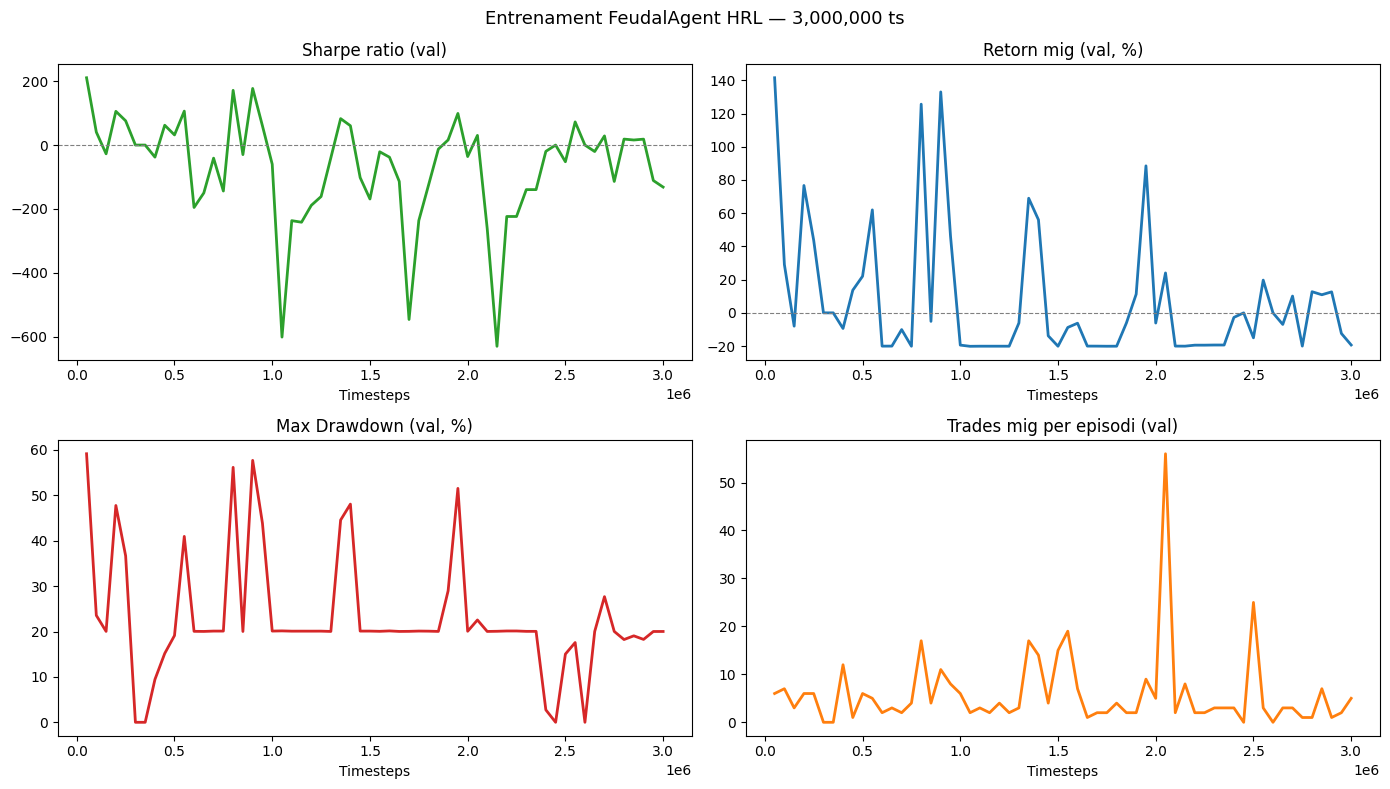

Guardat: results_sparse\05s_hrl_FeUdal_agent_paper_1ph_pt\nb04_sparse_training_curves.png


In [22]:
# CEL·LA 16 — CORBES D'ENTRENAMENT

if eval_history:
    ts_vals  = [h['timestep']    for h in eval_history]
    sh_vals  = [h['sharpe']      for h in eval_history]
    ret_vals = [h['mean_return'] for h in eval_history]
    dd_vals  = [h['max_drawdown']for h in eval_history]
    tr_vals  = [h['mean_trades'] for h in eval_history]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(ts_vals, sh_vals,  color='#2ca02c', linewidth=2)
    axes[0, 0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0, 0].set_title('Sharpe ratio (val)'); axes[0, 0].set_xlabel('Timesteps')

    axes[0, 1].plot(ts_vals, ret_vals, color='#1f77b4', linewidth=2)
    axes[0, 1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0, 1].set_title('Retorn mig (val, %)'); axes[0, 1].set_xlabel('Timesteps')

    axes[1, 0].plot(ts_vals, dd_vals,  color='#d62728', linewidth=2)
    axes[1, 0].set_title('Max Drawdown (val, %)'); axes[1, 0].set_xlabel('Timesteps')

    axes[1, 1].plot(ts_vals, tr_vals,  color='#ff7f0e', linewidth=2)
    axes[1, 1].set_title('Trades mig per episodi (val)'); axes[1, 1].set_xlabel('Timesteps')

    plt.suptitle(f'Entrenament FeudalAgent HRL — {FINAL_TIMESTEPS:,} ts', fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS / 'nb04_sparse_training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Guardat: {RESULTS / 'nb04_sparse_training_curves.png'}")
else:
    print('Sense historial d\'avaluacio.')


## 7. Avaluació Walk-Forward sobre el Test Split

Protocol idèntic a NB03b:
- L'agent recorre el test split sequüencialment (sense overlap)
- Cada episodi comença on va acabar l'anterior
- L'agent mai ha vist dades del test durant l'entrenament ni el tuning


In [23]:
# CEL·LA 17 — WALK-FORWARD TEST

print(f'Walk-forward sobre test split ({len(df_test):,} files)...')
wf_results = walk_forward_eval_hrl(
    agent_final, df_test, DEVICE,
    c=best_params['c'],
    ep_steps=MAX_EPISODE_STEPS,
    seed=SEED,
    log_project=PROJECT + '_test',
    log_dir=RESULTS,
)
m = wf_results['metrics']

print()
print('=' * 55)
print('  RESULTATS FeudalAgent — TEST SPLIT (walk-forward)')
print('=' * 55)
print(f"  Retorn total acumulat : {m['total_return']:>+10.2f} %")
print(f"  Sharpe ratio          : {m['sharpe']:>+10.4f}")
print(f"  Max drawdown          : {m['max_drawdown']:>10.2f} %")
print(f"  Episodis              : {m['n_episodes']:>10,}")
print(f"  Passos totals         : {m['n_steps']:>10,}")
print('  Distribucio accions:')
for act_name, pct in m['action_dist_pct'].items():
    bar = '#' * int(pct / 2)
    print(f'    {act_name:<6}: {pct:>6.2f} %  {bar}')
print('=' * 55)

p_arr = np.array(wf_results['prices'], dtype=np.float64)
if len(p_arr) > 0:
    bah = (p_arr[-1] / p_arr[0] - 1) * 100
    print(f'  Buy-and-Hold ref: {bah:>+8.2f}%')
    print(f'  Alpha vs B&H:     {m["total_return"] - bah:>+8.2f}%')


Walk-forward sobre test split (17,500 files)...
Log CSV (walk-forward): results_sparse\05s_hrl_FeUdal_agent_paper_1ph_pt\1415-260522_nb05d_hrl_feudal_test_log.csv

  RESULTATS FeudalAgent — TEST SPLIT (walk-forward)
  Retorn total acumulat :     -98.76 %
  Sharpe ratio          :    +1.0214
  Max drawdown          :      32.62 %
  Episodis              :         25
  Passos totals         :     16,987
  Distribucio accions:
    HOLD  :   3.62 %  #
    LONG  :   0.24 %  
    SHORT :  88.59 %  ############################################
    CLOSE :   7.55 %  ###
  Buy-and-Hold ref:  +121.02%
  Alpha vs B&H:      -219.77%


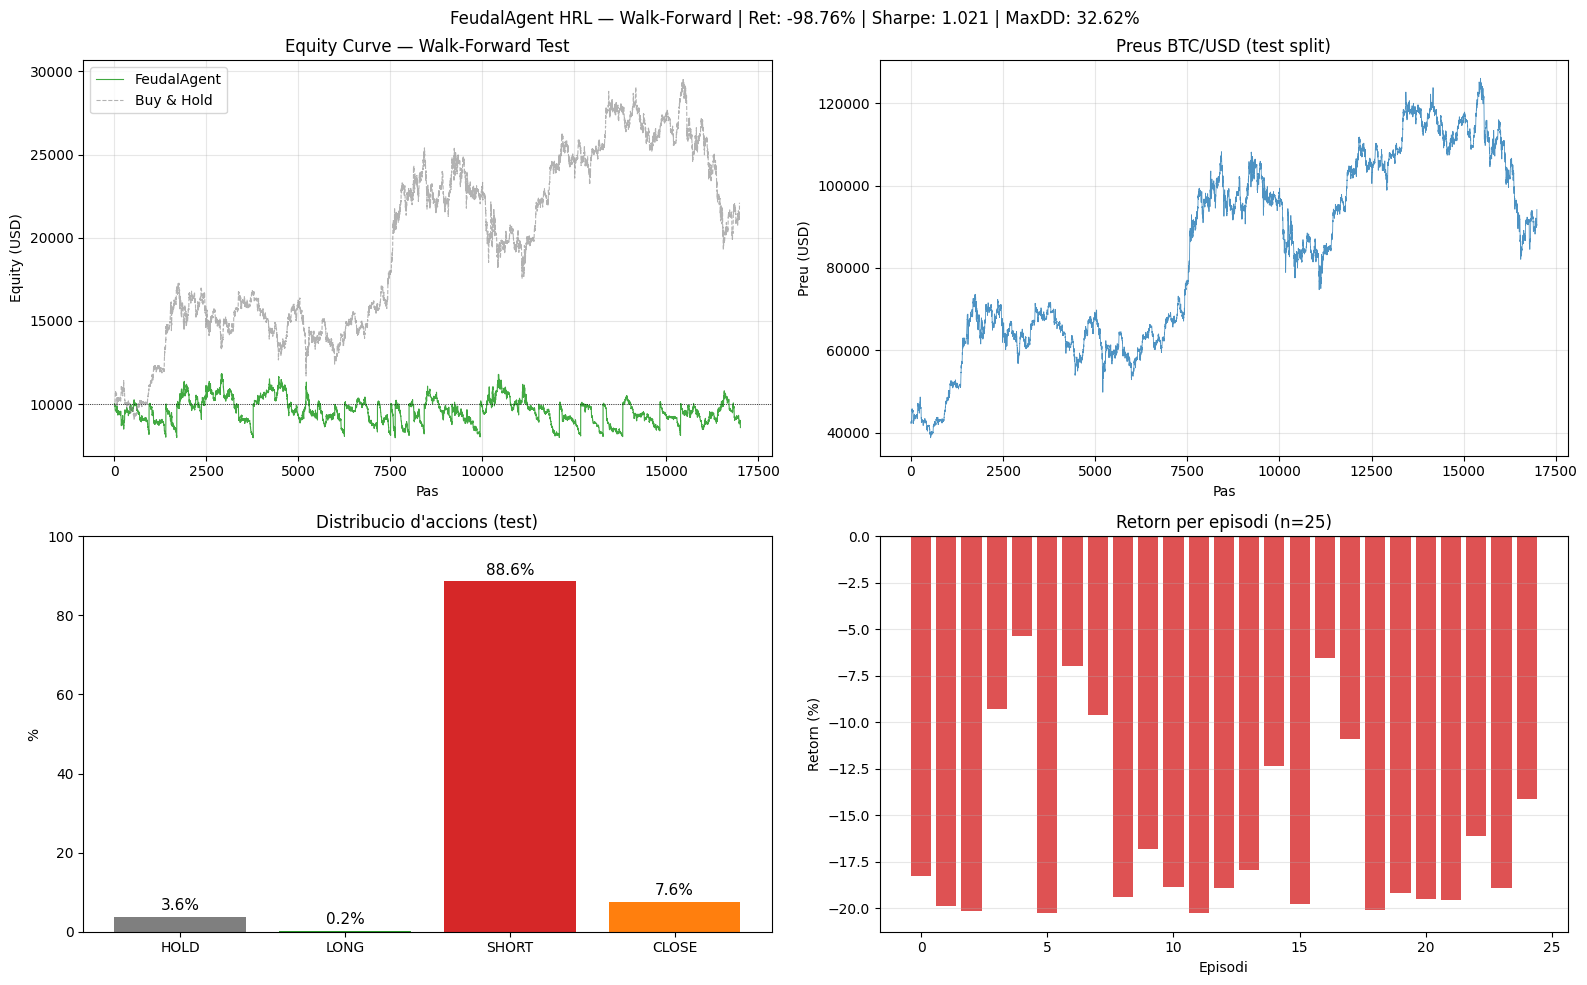

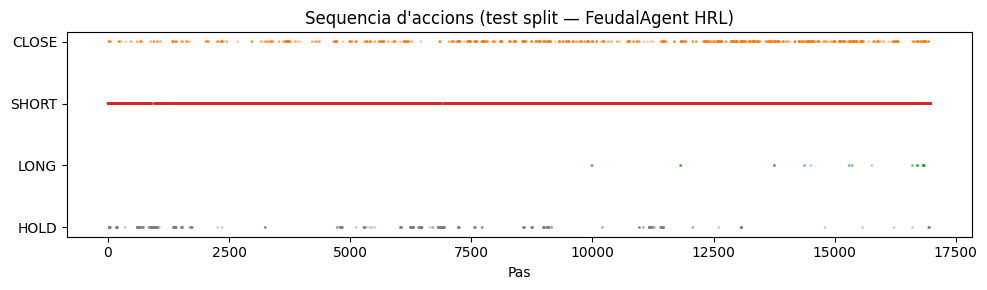

Guardat: results_sparse\05s_hrl_FeUdal_agent_paper_1ph_pt\nb04_sparse_wf_equity_curve.png


In [24]:
# CEL·LA 18 — VISUALITZACIÓ WALK-FORWARD

eq   = np.array(wf_results['equities'])
pr   = np.array(wf_results['prices'])
ep_r = np.array(wf_results['ep_returns'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Equity curve
axes[0, 0].plot(eq, color='#2ca02c', linewidth=0.8, alpha=0.9, label='FeudalAgent')
if len(pr) > 0:
    bh = INITIAL_BALANCE * pr / pr[0]
    axes[0, 0].plot(bh, color='gray', lw=0.8, ls='--', alpha=0.6, label='Buy & Hold')
axes[0, 0].axhline(INITIAL_BALANCE, color='black', lw=0.6, ls=':')
axes[0, 0].set_title('Equity Curve — Walk-Forward Test')
axes[0, 0].set_xlabel('Pas'); axes[0, 0].set_ylabel('Equity (USD)')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Preus BTC
axes[0, 1].plot(pr, color='#1f77b4', linewidth=0.6, alpha=0.8)
axes[0, 1].set_title('Preus BTC/USD (test split)')
axes[0, 1].set_xlabel('Pas'); axes[0, 1].set_ylabel('Preu (USD)')
axes[0, 1].grid(alpha=0.3)

# Distribucio d'accions
act_d      = m['action_dist_pct']
colors_bar = ['#7f7f7f', '#2ca02c', '#d62728', '#ff7f0e']
bars       = axes[1, 0].bar(act_d.keys(), act_d.values(), color=colors_bar)
axes[1, 0].set_title('Distribucio d\'accions (test)')
axes[1, 0].set_ylabel('%'); axes[1, 0].set_ylim(0, 100)
for bar, val in zip(bars, act_d.values()):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

# Retorn per episodi
colors_ep = ['#2ca02c' if r >= 0 else '#d62728' for r in ep_r]
axes[1, 1].bar(range(len(ep_r)), ep_r, color=colors_ep, alpha=0.8)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title(f'Retorn per episodi (n={len(ep_r)})')
axes[1, 1].set_xlabel('Episodi'); axes[1, 1].set_ylabel('Retorn (%)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'FeudalAgent HRL — Walk-Forward | '
    f"Ret: {m['total_return']:+.2f}% | Sharpe: {m['sharpe']:.3f} | MaxDD: {m['max_drawdown']:.2f}%",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(RESULTS / 'nb04_sparse_wf_equity_curve.png', dpi=120, bbox_inches='tight')
plt.show()

# Sequencia d'accions
actions    = wf_results['actions']
fig2, ax2  = plt.subplots(figsize=(10, 3))
colors_map = {0: '#7f7f7f', 1: '#2ca02c', 2: '#d62728', 3: '#ff7f0e'}
ax2.scatter(range(len(actions)), actions,
            c=[colors_map[a] for a in actions], s=1, alpha=0.3)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(['HOLD', 'LONG', 'SHORT', 'CLOSE'])
ax2.set_title('Sequencia d\'accions (test split — FeudalAgent HRL)')
ax2.set_xlabel('Pas')
plt.tight_layout()
plt.savefig(RESULTS / 'nb04_sparse_action_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardat: {RESULTS / 'nb04_sparse_wf_equity_curve.png'}")


In [25]:
# CEL·LA 19 — DESAR MÈTRIQUES FINALS

# Fallbacks per si Optuna no s'ha executat en aquesta sessio
try:
    _study_val = study.best_value if "study" in dir() else None
except ValueError:
    _study_val = _best_val_p1 if "_best_val_p1" in dir() else None
_best_src  = best_source      if "best_source" in dir() else "manual (Optuna no executada)"
_best_ret  = float(best_val_return) if "best_val_return" in dir() else None
_em_opt    = float(emissions_optuna) if "emissions_optuna" in dir() else 0.0
_em_ref    = float(emissions_refine) if "emissions_refine" in dir() else 0.0
_em_fin    = float(emissions_final)  if "emissions_final"  in dir() else 0.0

_n_params_final = sum(p.numel() for p in agent_final.parameters())

results_dict = {
    'agent':     'HRL_FeUdal_Multiplicative_CustomPPO',
    'framework': 'PyTorch (from scratch)',
    'architecture': {
        'z_dim':          Z_DIM,
        'g_dim':          G_DIM,
        'k_dim':          K_DIM,
        'manager_hidden': MANAGER_HIDDEN,
        'worker_hidden':  WORKER_HIDDEN,
        'n_params':       _n_params_final,
        'note': 'Multiplicative goal integration: U·w policy in Worker',
    },
    'walk_forward': {
        'train_rows': len(df_train),
        'val_rows':   len(df_val),
        'test_rows':  len(df_test),
    },
    'optuna': {
        'n_trials':         N_TRIALS,
        'n_trials_refine':  N_TRIALS_REFINE,
        'tune_ts':          TUNE_TIMESTEPS,
        'best_return_p1':   _study_val,
        'best_source':      _best_src,
        'best_val_return':  _best_ret,
        'best_params':      best_params,
    },
    'training': {
        'final_timesteps': FINAL_TIMESTEPS,
        'config':          final_cfg,
    },
    'test_metrics':       wf_results['metrics'],
    'eval_history_final': eval_history,
    'sustainability': {
        'emissions_optuna_kg': _em_opt,
        'emissions_refine_kg': _em_ref,
        'emissions_final_kg':  _em_fin,
        'emissions_total_g':   (_em_opt + _em_ref + _em_fin) * 1000,
    },
}

out_path = RESULTS / 'nb04_sparse_hrl_feudal_metrics.json'
with open(out_path, 'w', encoding='utf-8') as fh:
    json.dump(results_dict, fh, indent=2, default=str, ensure_ascii=False)

print(f'Resultats desats: {out_path}')
print()
print('RESUM FINAL')
print('=' * 55)
print(f'  Agent:            FeudalAgent HRL Multiplicatiu')
print(f'  z_dim/g_dim/k_dim: {Z_DIM}/{G_DIM}/{K_DIM}')
print(f'  Params:           {_n_params_final:,}')
print(f'  Timesteps:        {FINAL_TIMESTEPS:,}')
print(f'  Optuna:           {N_TRIALS}+{N_TRIALS_REFINE} trials')
m = wf_results['metrics']
print(f'  Test retorn:      {m["total_return"]:+.2f}%')
print(f'  Test Sharpe:      {m["sharpe"]:.4f}')
print(f'  Test MaxDD:       {m["max_drawdown"]:.2f}%')
print(f'  CO2 total:        {results_dict["sustainability"]["emissions_total_g"]:.3f} g CO2eq')
print('=' * 55)
print('NB04-sparse completat')


Resultats desats: results_sparse\05s_hrl_FeUdal_agent_paper_1ph_pt\nb04_sparse_hrl_feudal_metrics.json

RESUM FINAL
  Agent:            FeudalAgent HRL Multiplicatiu
  z_dim/g_dim/k_dim: 64/32/8
  Params:           46,786
  Timesteps:        3,000,000
  Optuna:           50+20 trials
  Test retorn:      -98.76%
  Test Sharpe:      1.0214
  Test MaxDD:       32.62%
  CO2 total:        133.749 g CO2eq
NB04-sparse completat


## 8. Verificació: `src.FeudalAgent.load()` ≡ `agent_final`

Comprova que carregar el checkpoint des de `src/rl/agents/feudal_agent.py` dona resultats **numèricament idèntics** als obtinguts directament amb `agent_final` (cel·la anterior).

El `FeudalAgent` de `src/` és la còpia literal de la classe definida en aquest notebook, extreta perquè pugui ser importada des de qualsevol notebook d'avaluació o agent posterior sense redefinir-la in-line.


In [28]:
# VERIFICACIÓ: src.FeudalAgentV6.load() ≡ agent_final
# Comprova que carregar el .pt des de src dona resultats idèntics
# a l'avaluació feta directament amb agent_final.

import importlib
import src.rl.agents.feudal_agent_v6 as _mod
importlib.reload(_mod)
from src.rl.agents.feudal_agent_v6 import FeudalAgentV6 as _FA_src


# ── Càrrega des de src ──────────────────────────────────────────────────────────
CKPT_PATH   = HRL_CKPT_DIR / 'hrl_feudal_best.pt'
agent_src   = _FA_src.load(CKPT_PATH, device=DEVICE)
params_src  = agent_src.count_params()
print(f'Carregat des de src: {params_src["total"]:,} params total')
print(f'  z_dim={agent_src.z_dim}  g_dim={agent_src.g_dim}  k_dim={agent_src.k_dim}')

# Verificació de pesos: han de ser idèntics als de agent_final
n_checked = 0
for key, w_orig in agent_final.state_dict().items():
    w_load = agent_src.state_dict()[key]
    assert torch.allclose(w_orig.cpu(), w_load.cpu()), f'Divergència en capa: {key}'
    n_checked += 1
print(f'Pesos idèntics a agent_final ({n_checked} tensors verificats) ✓')

# ── Walk-forward amb l'agent carregat des de src ────────────────────────────
print()
print('Walk-forward amb src.FeudalAgentV6.load() ...')
wf_src = walk_forward_eval_hrl(
    agent_src, df_test, DEVICE,
    c=best_params['c'],
    ep_steps=MAX_EPISODE_STEPS,
    seed=SEED,
    log_project=PROJECT + '_src_verify',
    log_dir=RESULTS,
)

# ── Comparació numèrica ─────────────────────────────────────────────────────────
m_orig = wf_results['metrics']
m_src  = wf_src['metrics']

print()
print(f"{'='*62}")
print(f"  {'Mètrica':<22} {'agent_final':>16} {'src.load()':>16}  OK")
print(f"  {'-'*60}")
for key in ['total_return', 'sharpe', 'max_drawdown', 'n_steps']:
    v1, v2 = m_orig[key], m_src[key]
    ok_sym = '✓' if abs(v1 - v2) < 1e-4 else '✗'
    print(f'  {key:<22} {v1:>+16.4f} {v2:>+16.4f}  {ok_sym}')
print(f"{'='*62}")

# Verifica accions idèntiques
acts_orig = wf_results['actions']
acts_src  = wf_src['actions']
if acts_orig == acts_src:
    print('Seqüència d\'accions idèntica ✓')
else:
    diff_count = sum(a != b for a, b in zip(acts_orig, acts_src))
    print(f'ATENCIÓ: {diff_count} accions difereixen (possible no-determinisme)')

print()
print('NB05d_6 — Verificació src.FeudalAgentV6 OK')


Carregat des de src: 46,786 params total
  z_dim=64  g_dim=32  k_dim=8
Pesos idèntics a agent_final (31 tensors verificats) ✓

Walk-forward amb src.FeudalAgentV6.load() ...
Log CSV (walk-forward): results_sparse\05s_hrl_FeUdal_agent_paper_1ph_pt\1428-260522_nb05d_hrl_feudal_src_verify_log.csv

  Mètrica                     agent_final       src.load()  OK
  ------------------------------------------------------------
  total_return                   -98.7577         -98.7577  ✓
  sharpe                          +1.0214          +1.0214  ✓
  max_drawdown                   +32.6210         +32.6210  ✓
  n_steps                     +16987.0000      +16987.0000  ✓
Seqüència d'accions idèntica ✓

NB05d_6 — Verificació src.FeudalAgentV6 OK
